In [545]:
import numpy as np
import subprocess
import os
import sys
sys.path.append("/home/nichettg/Linux Programmi/Codici")
import importlib

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import itertools
import grafici as gf
importlib.reload(gf)

from scipy.stats import norm, chi2
import funzioni as f
importlib.reload(f)
import tabulate

In [528]:
bin = 1
# Inclusione grafici Mengoni
M = True
# Zoom del grafico
i1 = 310
i2 = 340
i3 = 390
i4 = 400

# 1. Raccolta Dati

### 1.1 Lettura Cartella Raw

In [529]:
if M == True:
    input_files = [f"./Raw/{f}" for f in sorted(os.listdir('./Raw'))]
else:
    input_files = [f"./Raw/{f}" for f in os.listdir('./Raw') if 'M' not in f and 'h' in f]

### 1.2 Creazione Liste

In [530]:
output_files,titoli=[],[]
for input in input_files:
    output_files.append(input.replace('.csv', '.txt').replace('Raw','Data'))
    titoli.append(input.replace('.csv','').replace("./Raw/","").replace("Ispector_65_Spectrum_","")[2:])

### 1.3 Conversione RawToData

In [531]:
for input, output in zip(input_files,output_files):
     try:
          subprocess.run(['./RawToData.exe', '-in', input, '-out', output, '-rebin', str(bin)], stdout=subprocess.DEVNULL, check=True)
          print(f"{input:<50} convertito con successo")
     except subprocess.CalledProcessError as e:
          print(f"Errore durante l'esecuzione: {e}")

./Raw/01Ispector_65_Spectrum_2min.csv              convertito con successo
./Raw/02Ispector_65_Spectrum_11min.csv             convertito con successo
./Raw/03Ispector_65_Spectrum_20min.csv             convertito con successo
./Raw/04Ispector_65_Spectrum_40min.csv             convertito con successo
./Raw/05Ispector_65_Spectrum_1h.csv                convertito con successo
./Raw/06Ispector_65_Spectrum_M_1h10m.csv           convertito con successo
./Raw/07Ispector_65_Spectrum_1h20m.csv             convertito con successo
./Raw/08Ispector_65_Spectrum_M_2h.csv              convertito con successo
./Raw/09Ispector_65_Spectrum_M_3h17m.csv           convertito con successo
./Raw/10Ispector_65_Spectrum_M_6h20m.csv           convertito con successo
./Raw/11Ispector_65_Spectrum_M_14h03m.csv          convertito con successo
./Raw/12Ispector_65_Spectrum_M_background.csv      convertito con successo
./Raw/13Ispector_65_Spectrum_M_carnotite.csv       convertito con successo


# 2. Grafici e Fit

### 2.1 Funzioni

In [532]:
def exp_func(x, a, b, c):
    return a * np.exp(b * x) + c

def lin_func(x, a, b):
    return a + b * x

### 2.2 Indici

In [533]:
rows = [
    ["i1", i1],
    ["i2", i2],
    ["i3", i3],
    ["i4", i4],
]

headers = ["Indici", ""]

print(tabulate.tabulate(rows, headers=headers, floatfmt=".0f"))

Indici
--------  ---
i1        310
i2        340
i3        390
i4        400


### 2.2 Calcolo Fit

Vengono calcolati i parametri di un interpolazione lineare rispetto ai dati al di fuori dell'ipotesi di picco. La regressione è minimi quadrati II, avendo considerato le incertezze con $$\sigma = \sqrt f_i$$ con $f$ come frequenza di ogni colonna. Viene anche eseguita l'analisi dei vari test statitici nella cartella Elaborati.

Fit Lineare


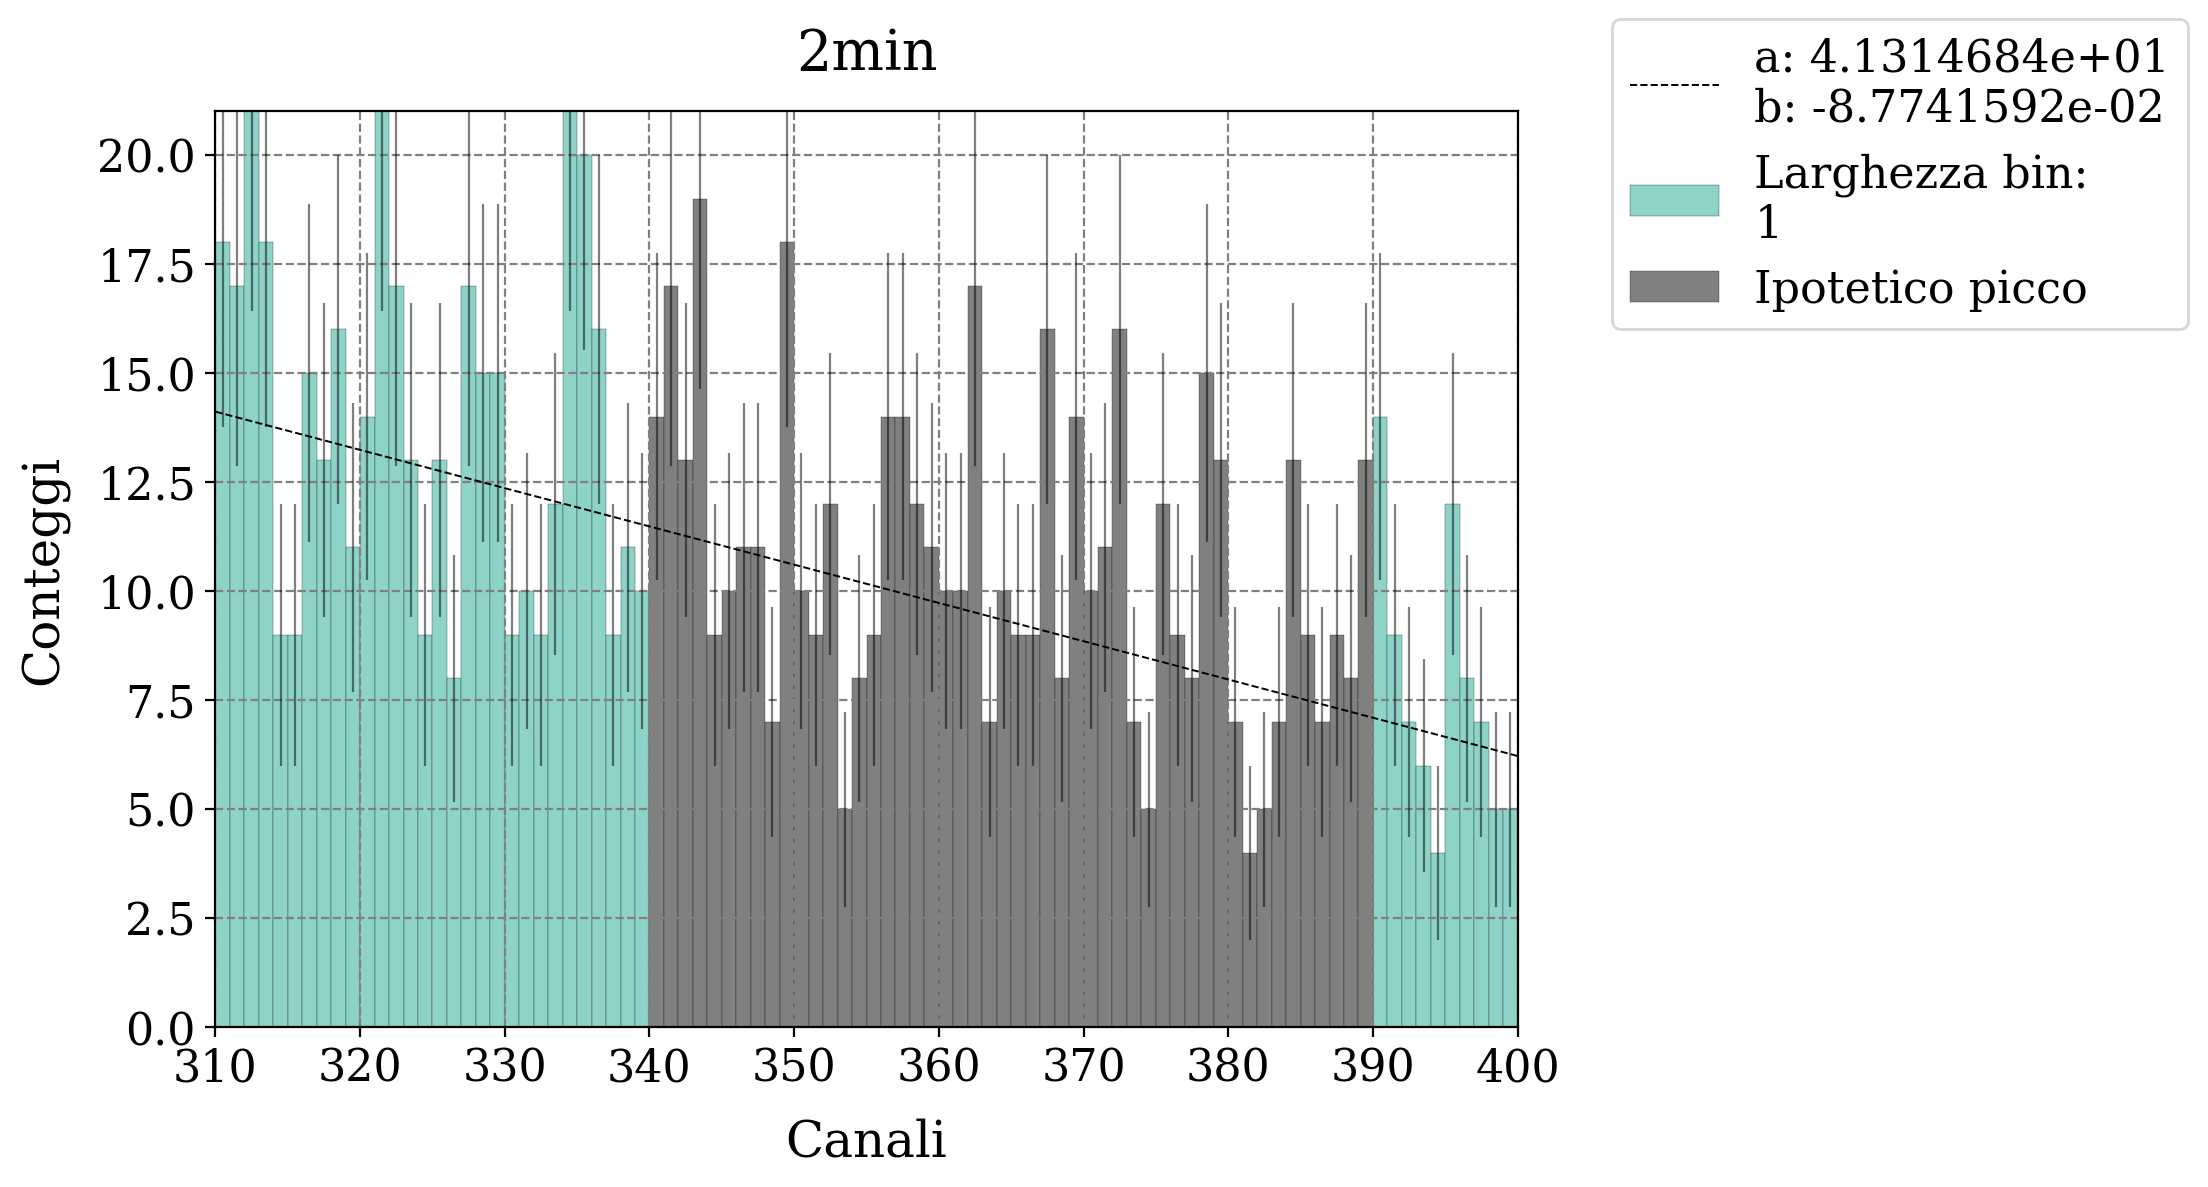

Fit Lineare


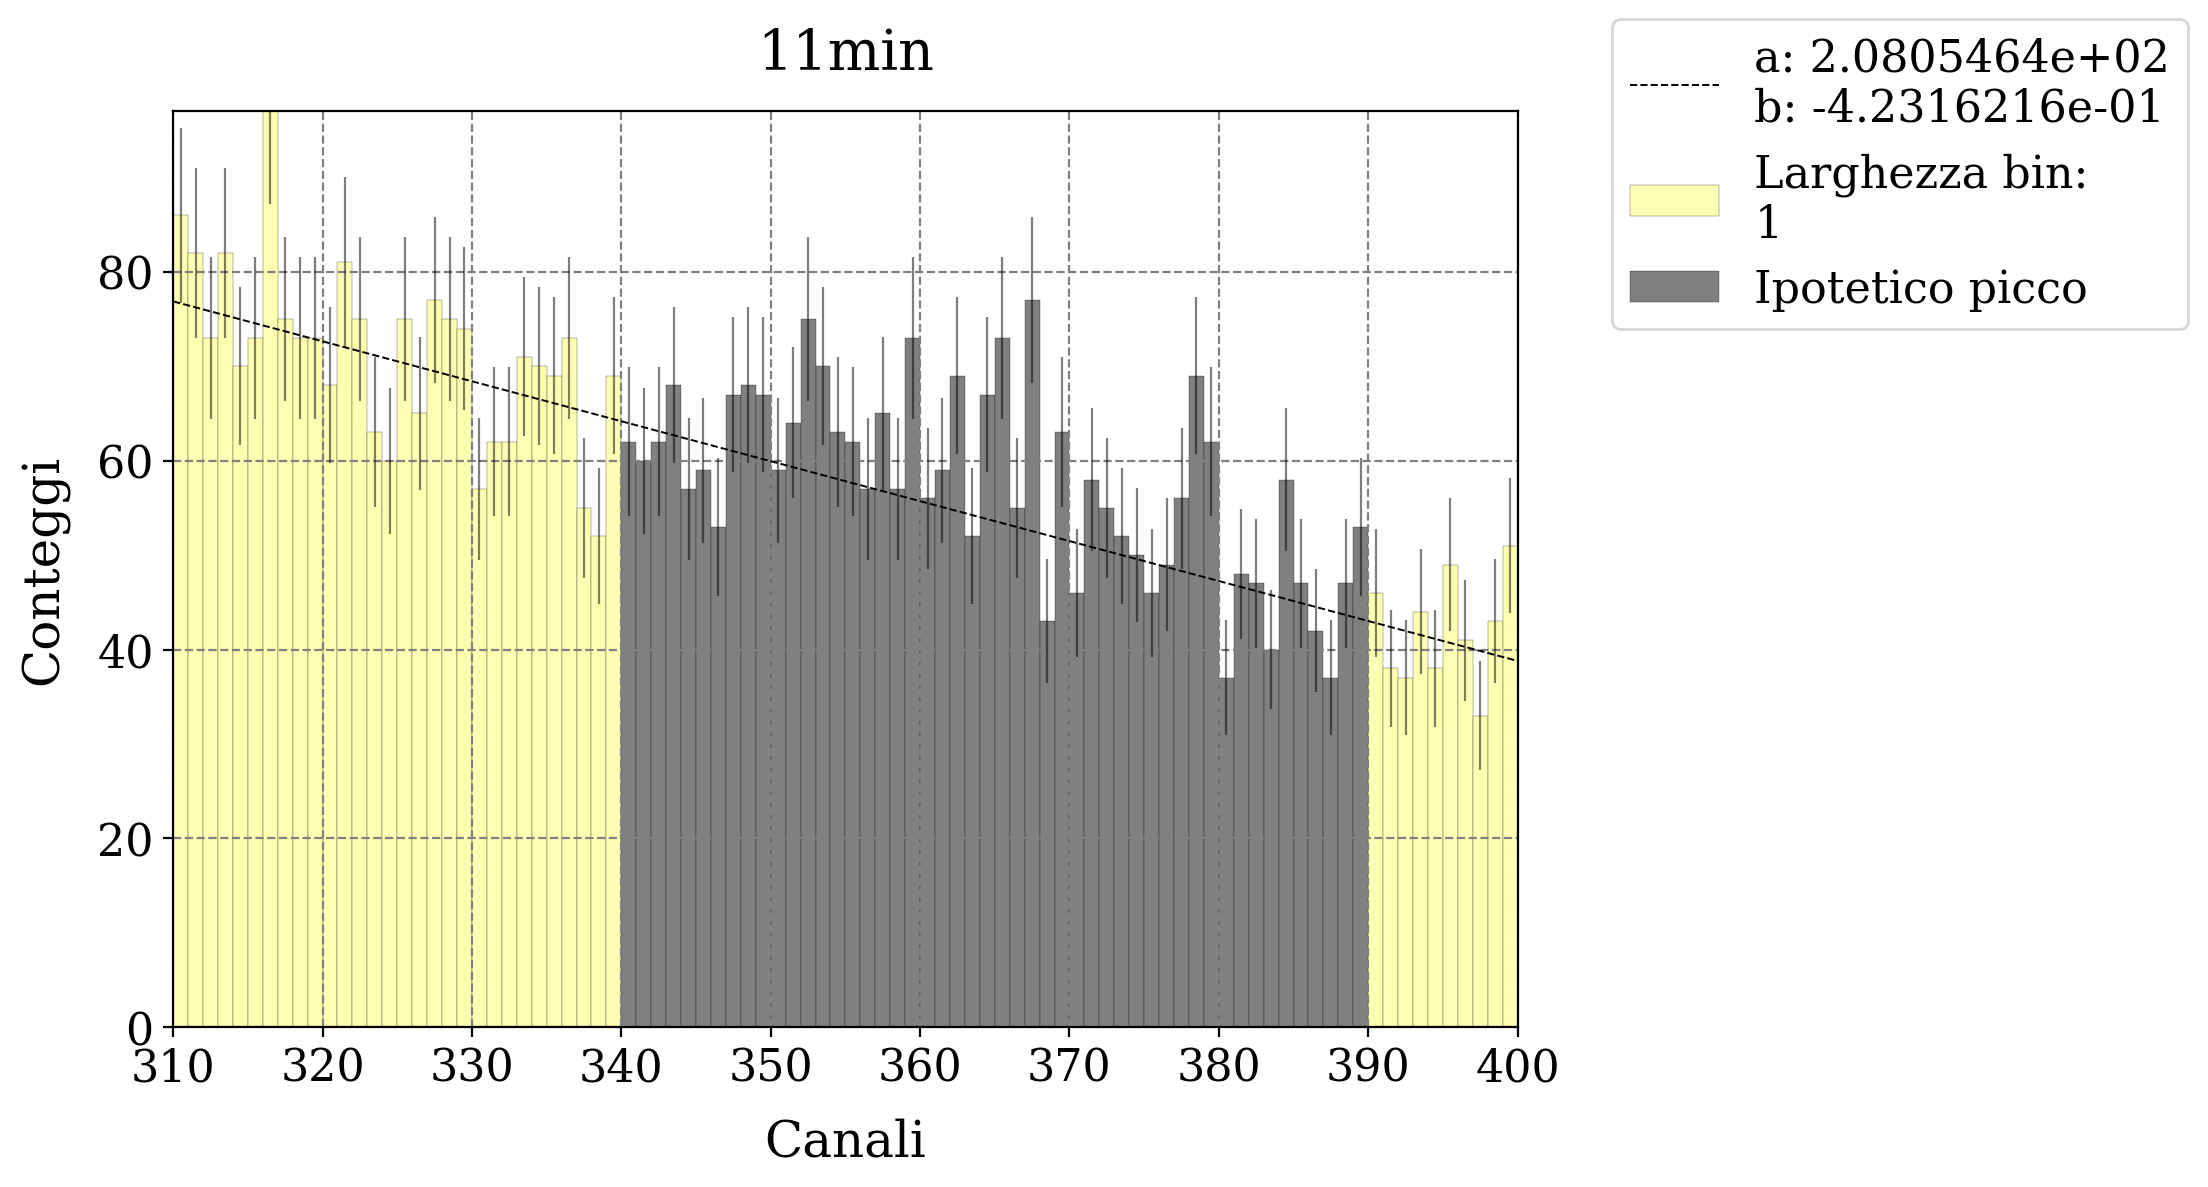

Fit Lineare


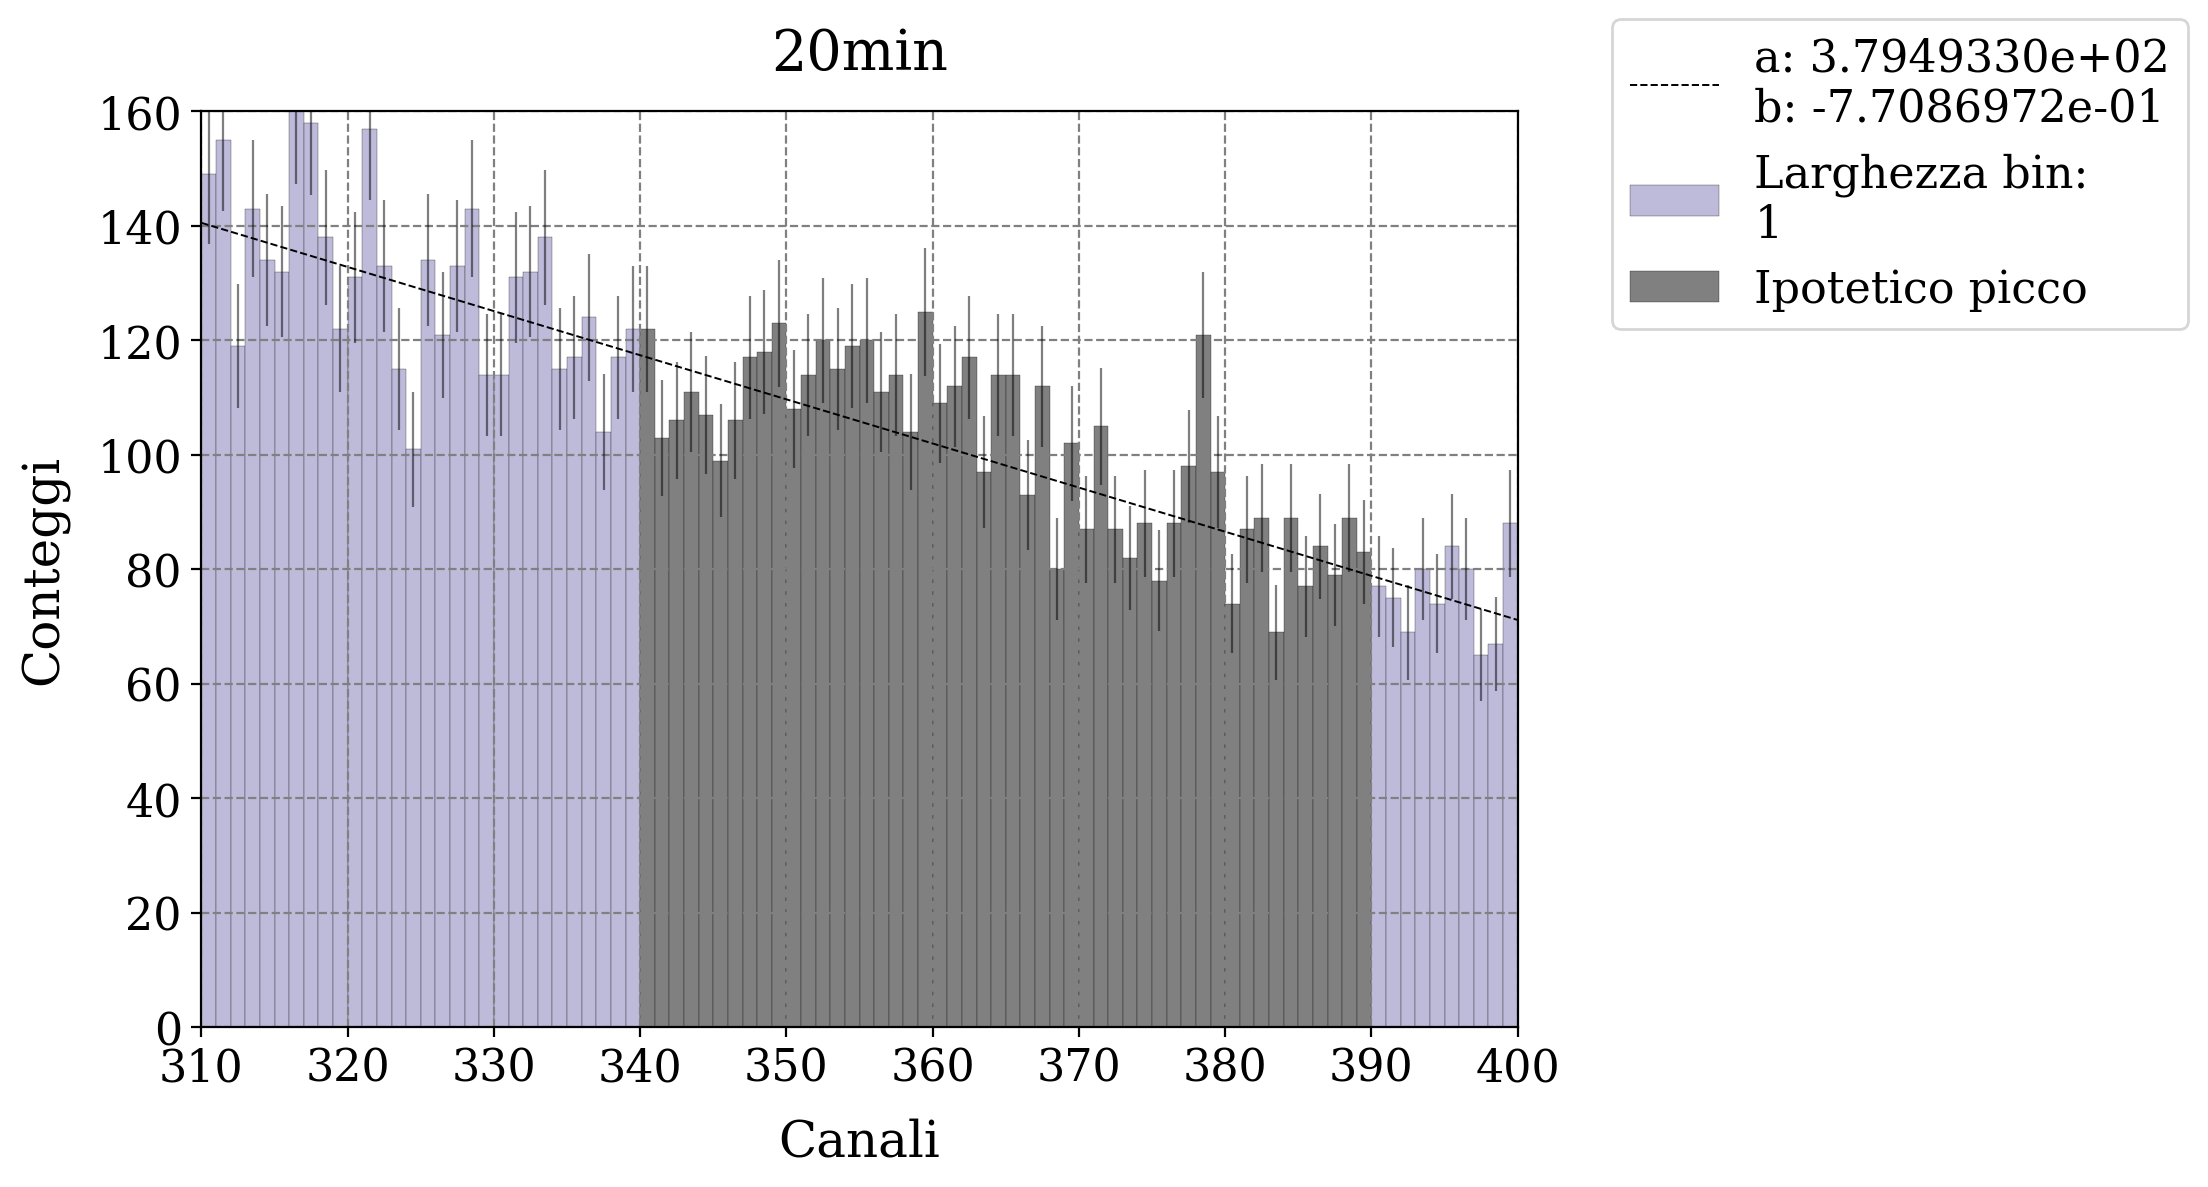

Fit Lineare


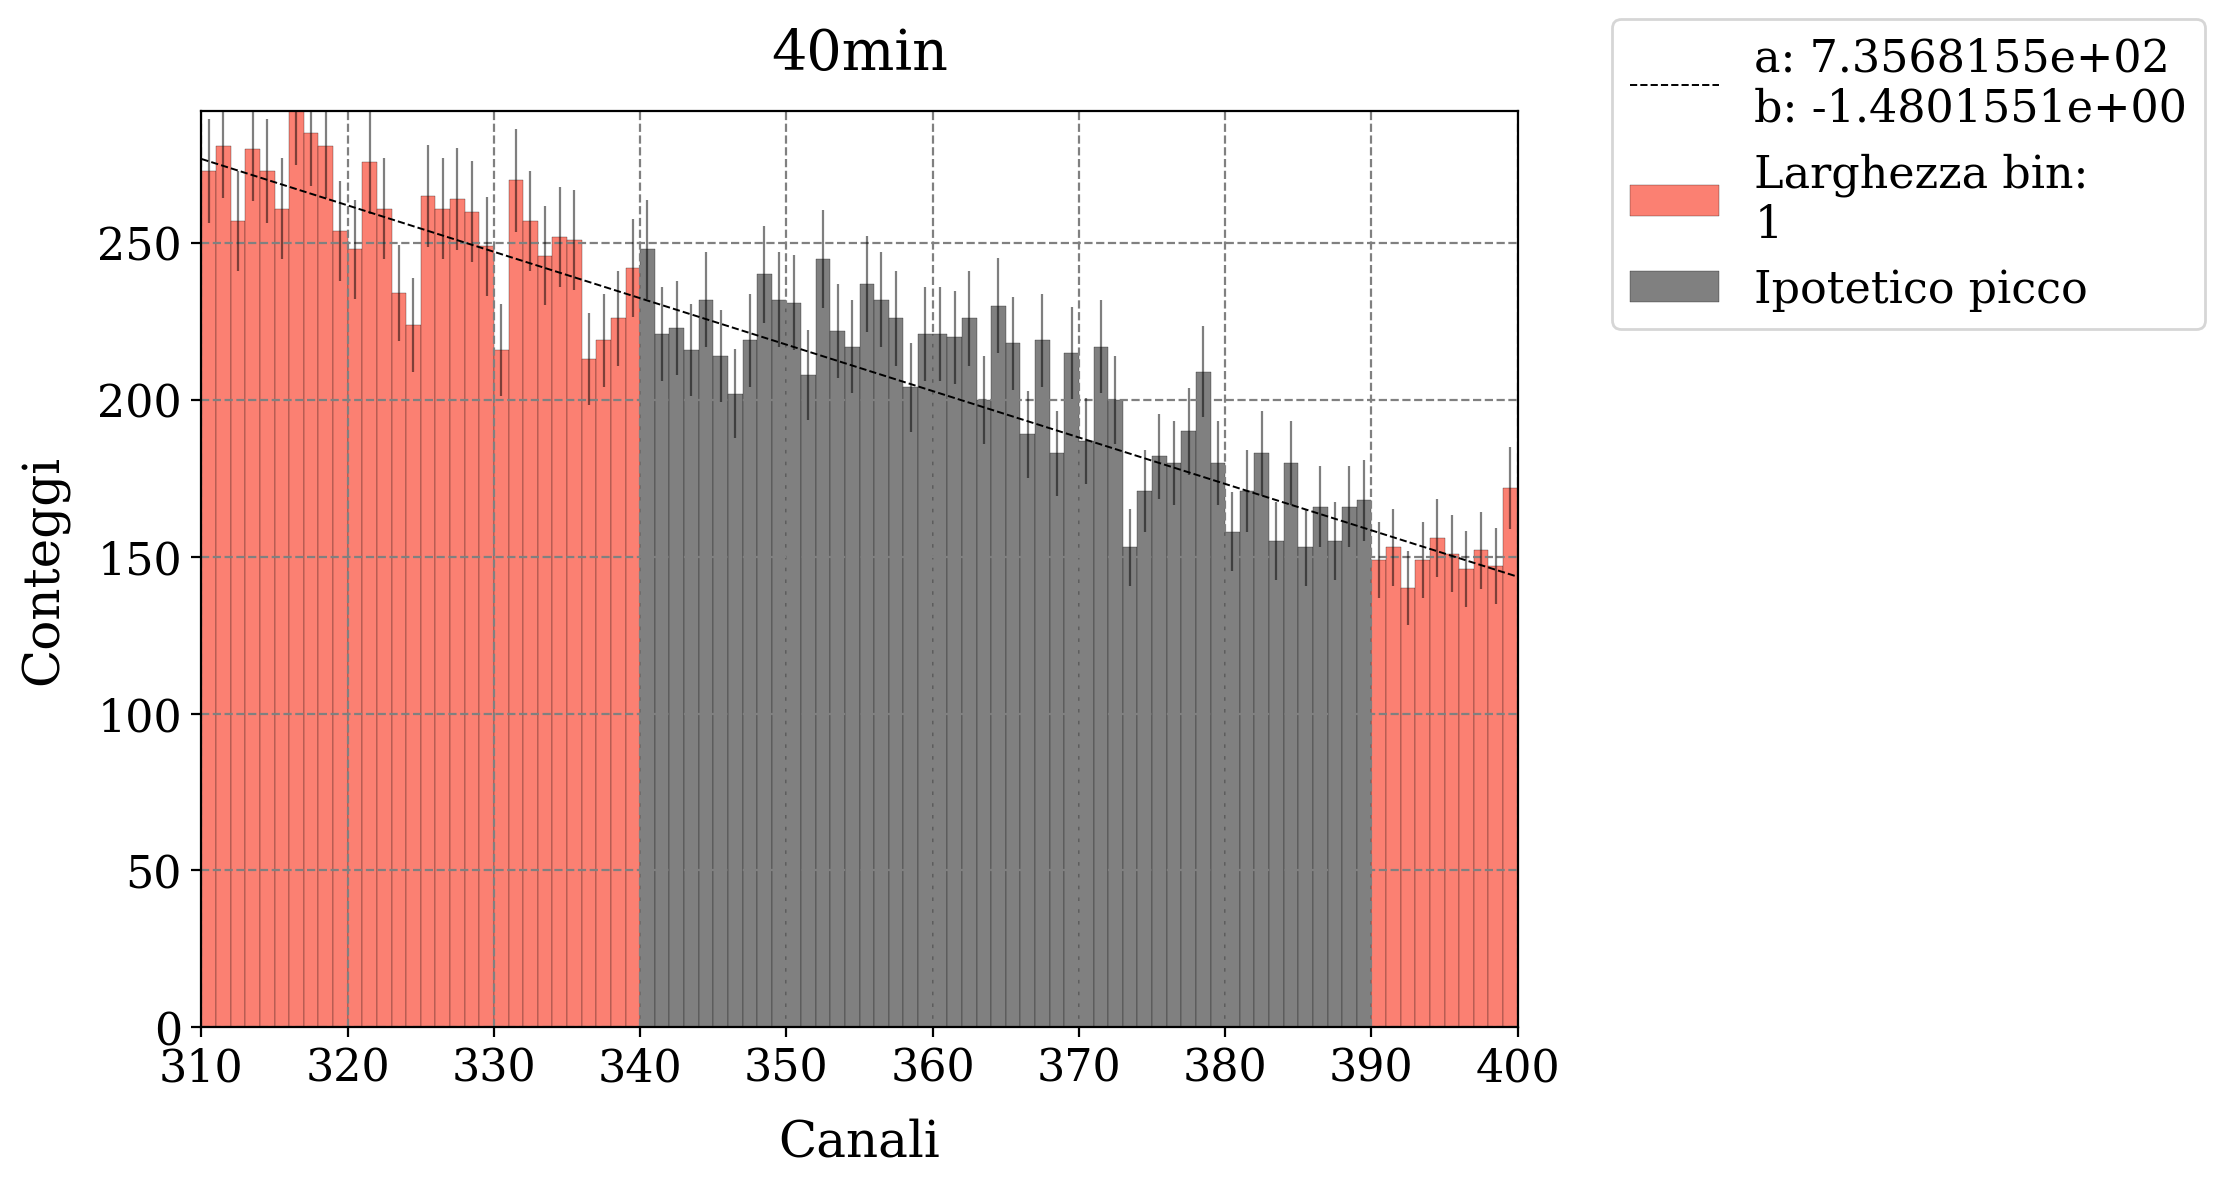

Fit Lineare


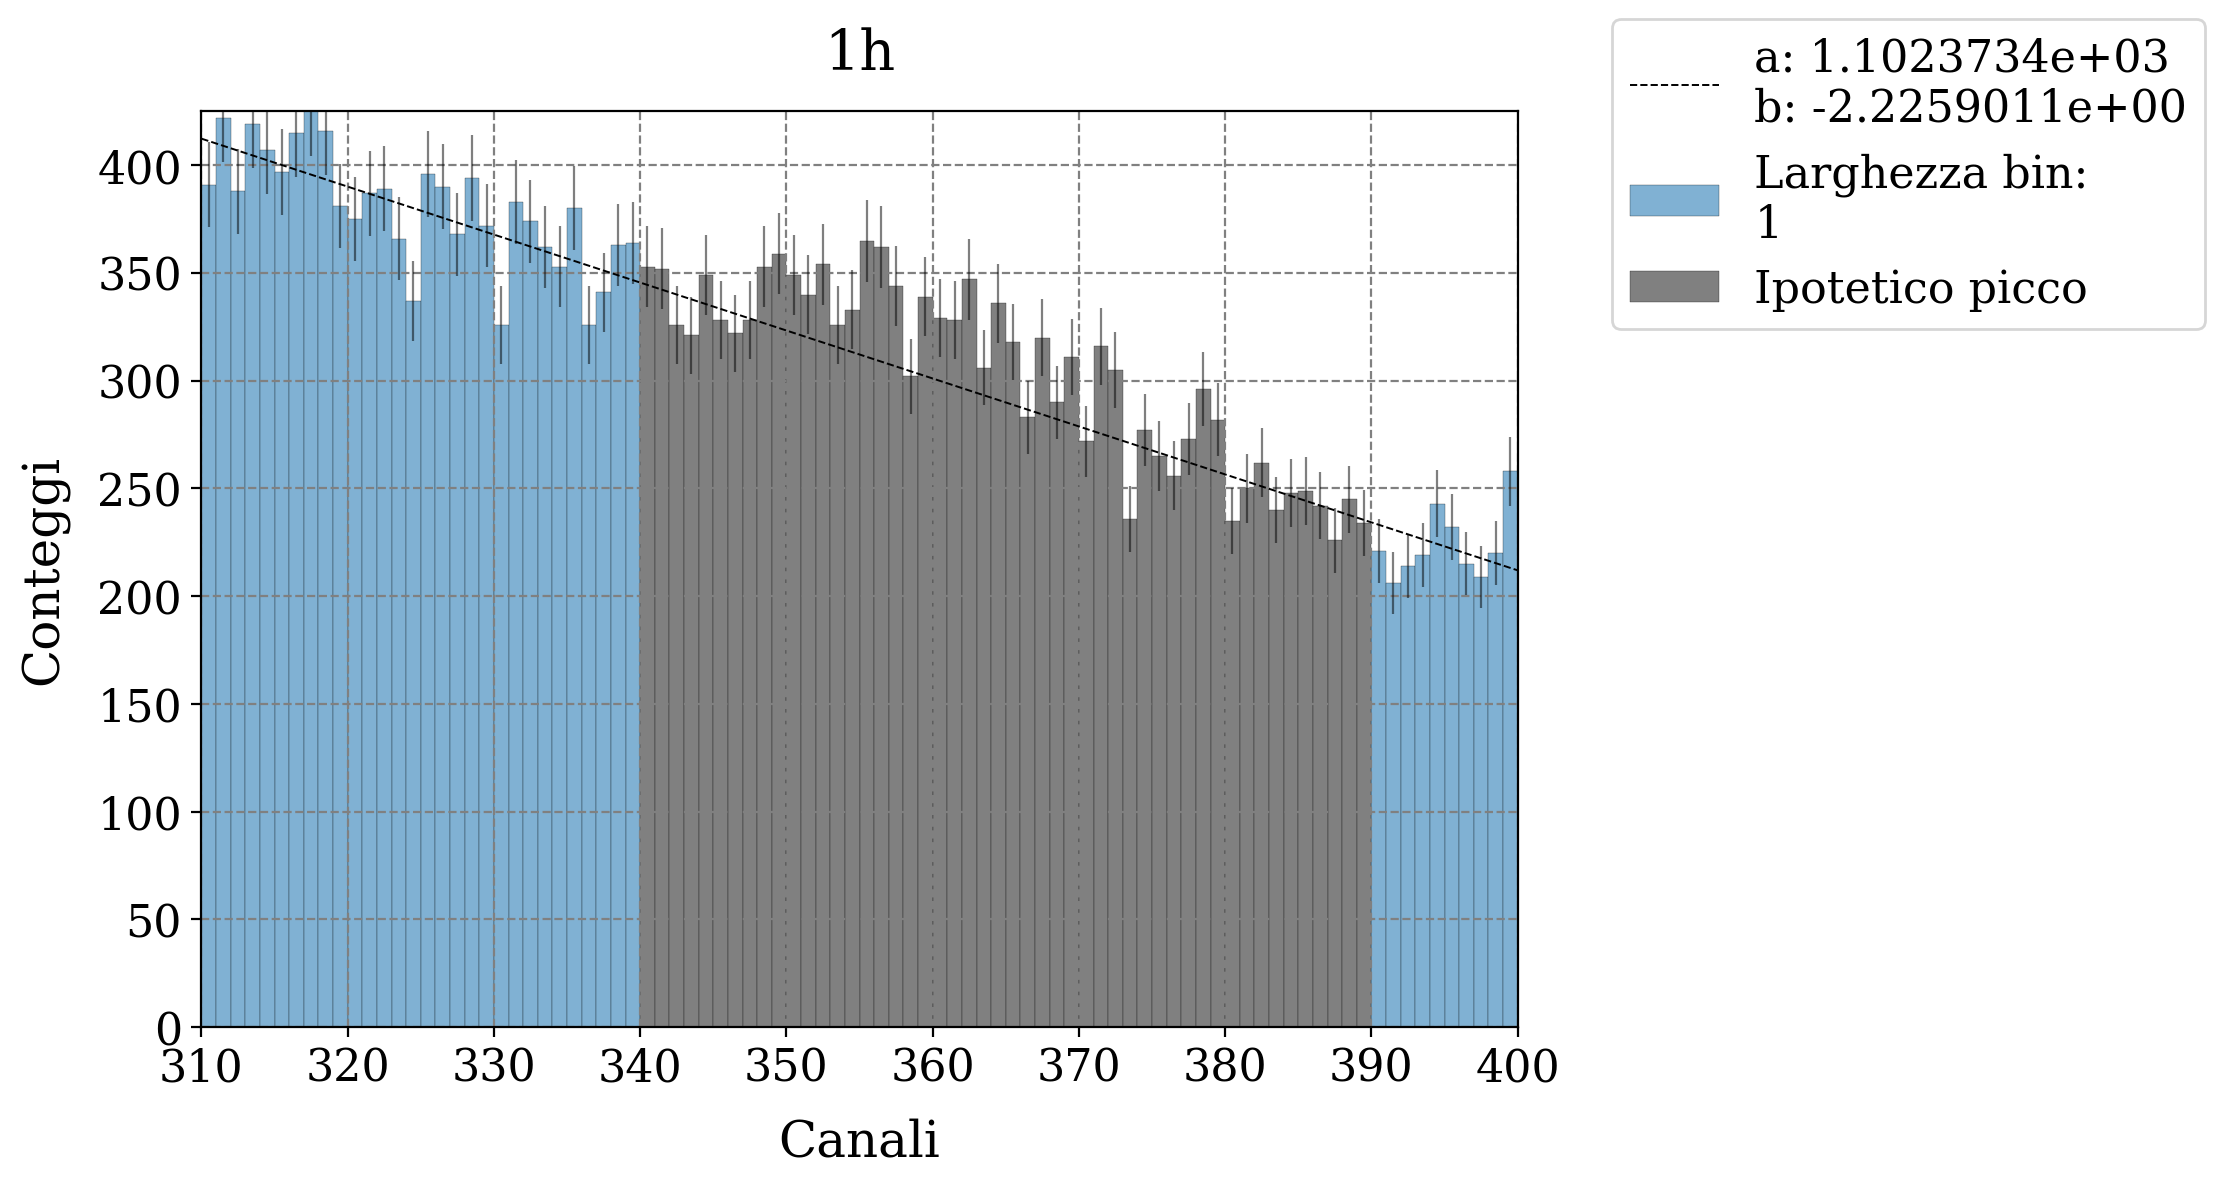

Fit Lineare


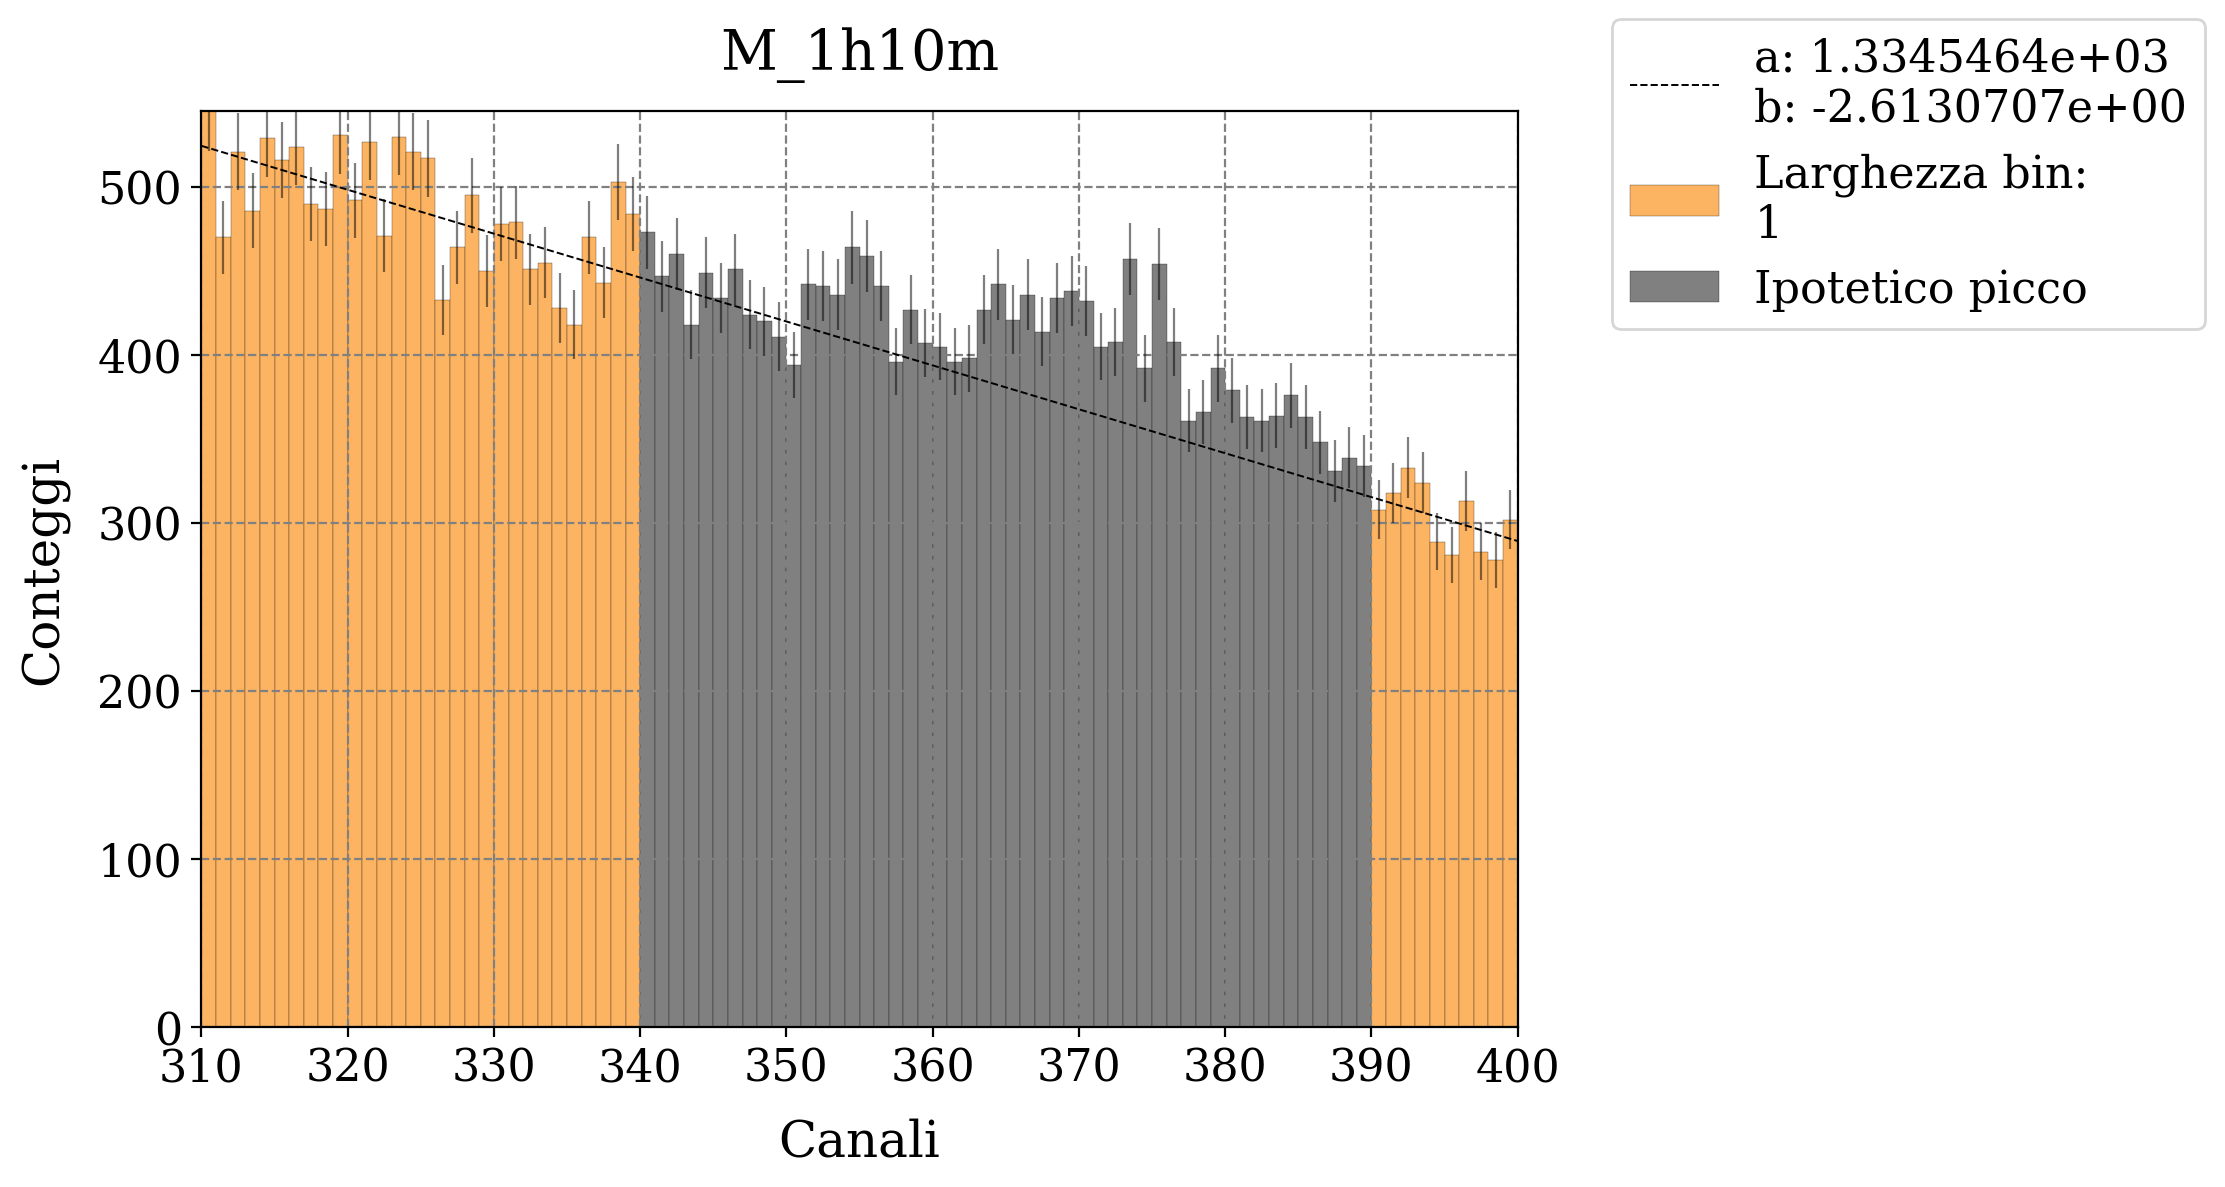

Fit Lineare


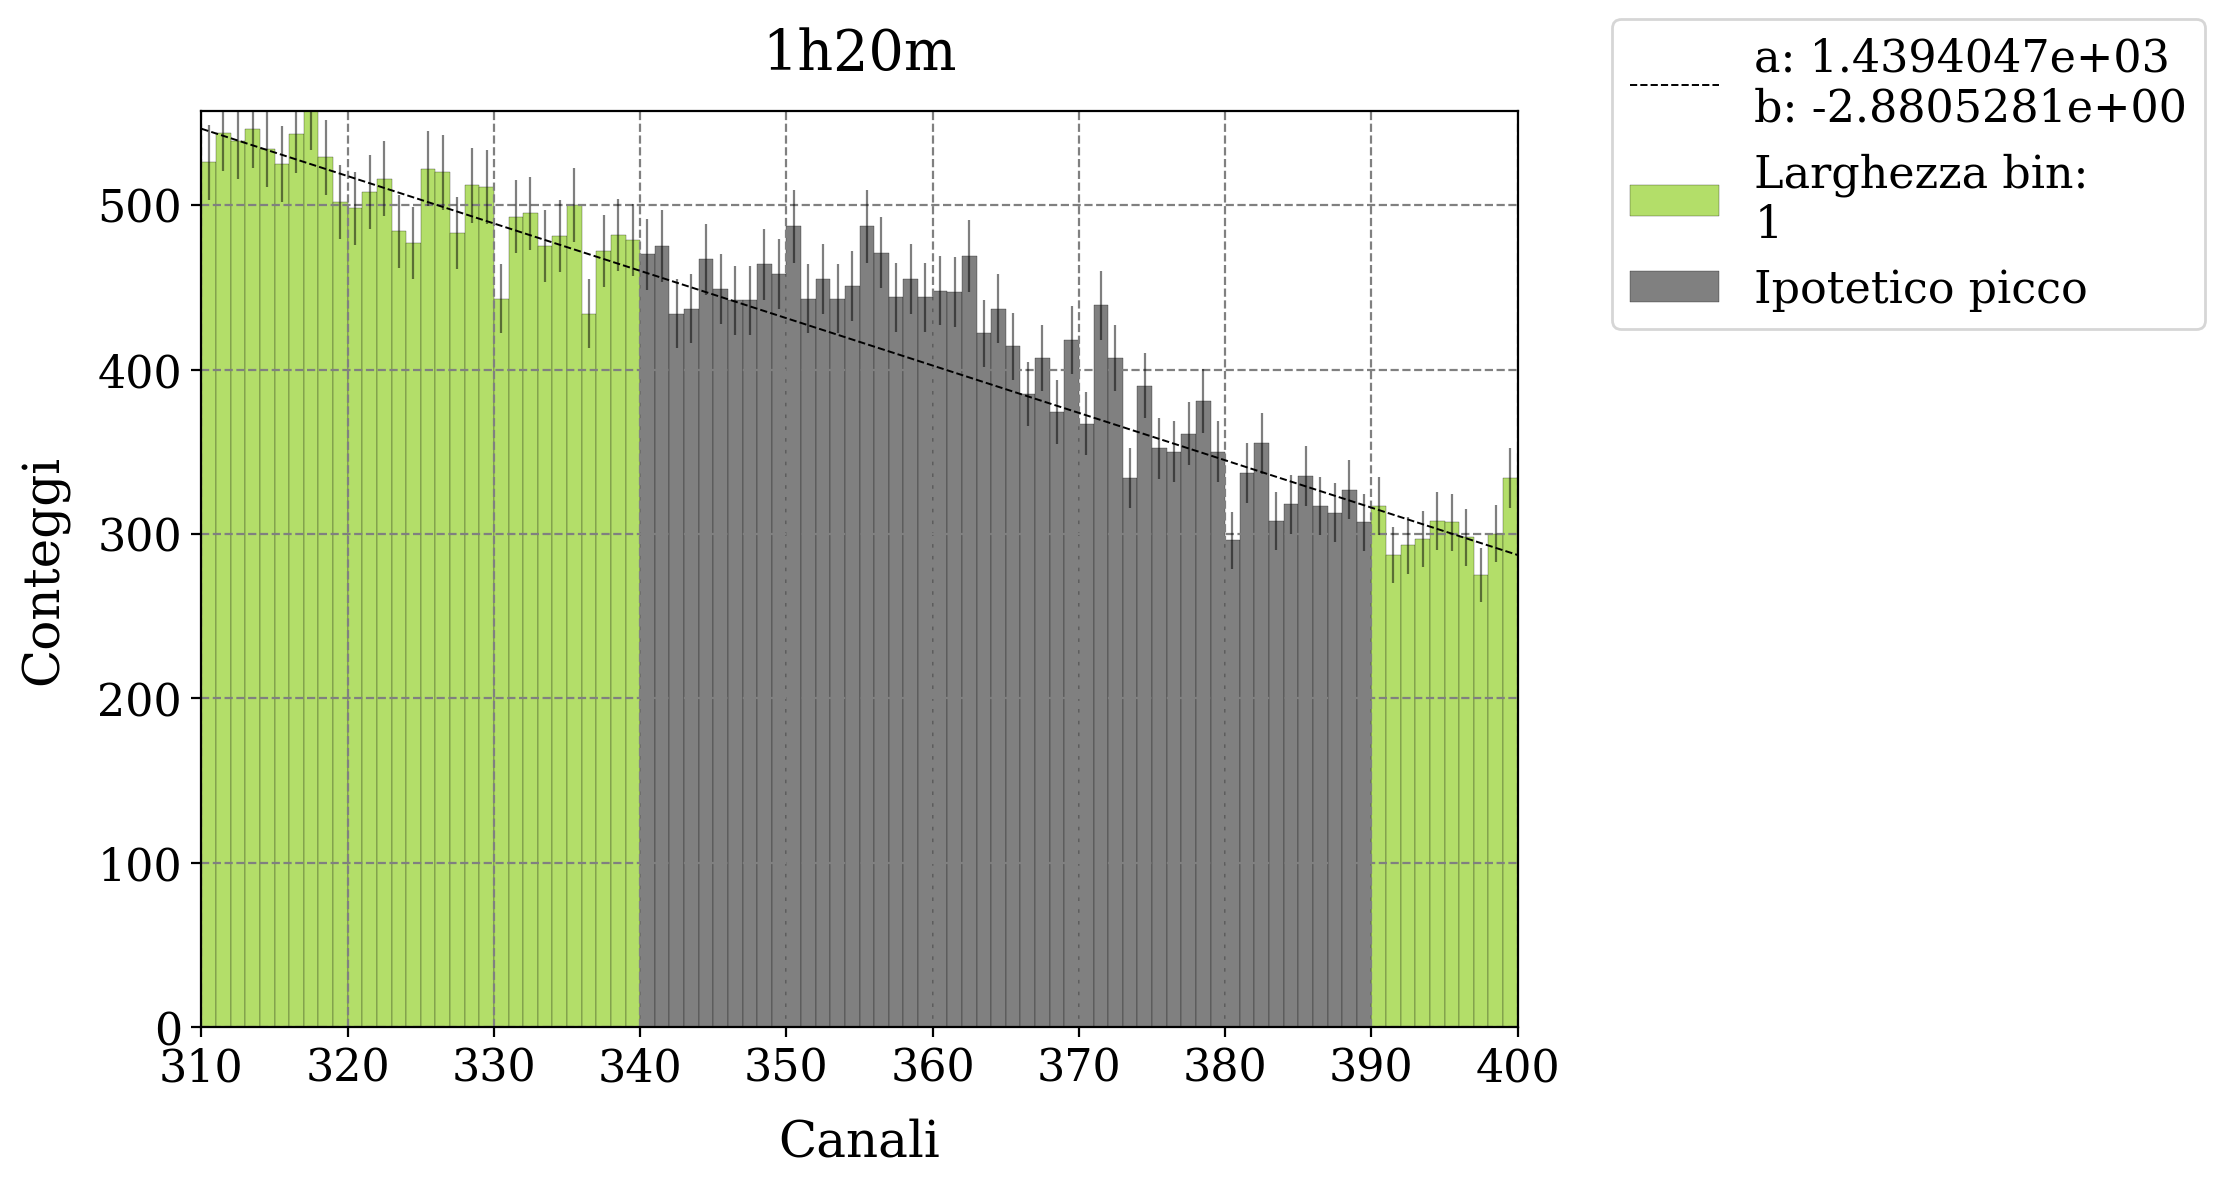

Fit Lineare


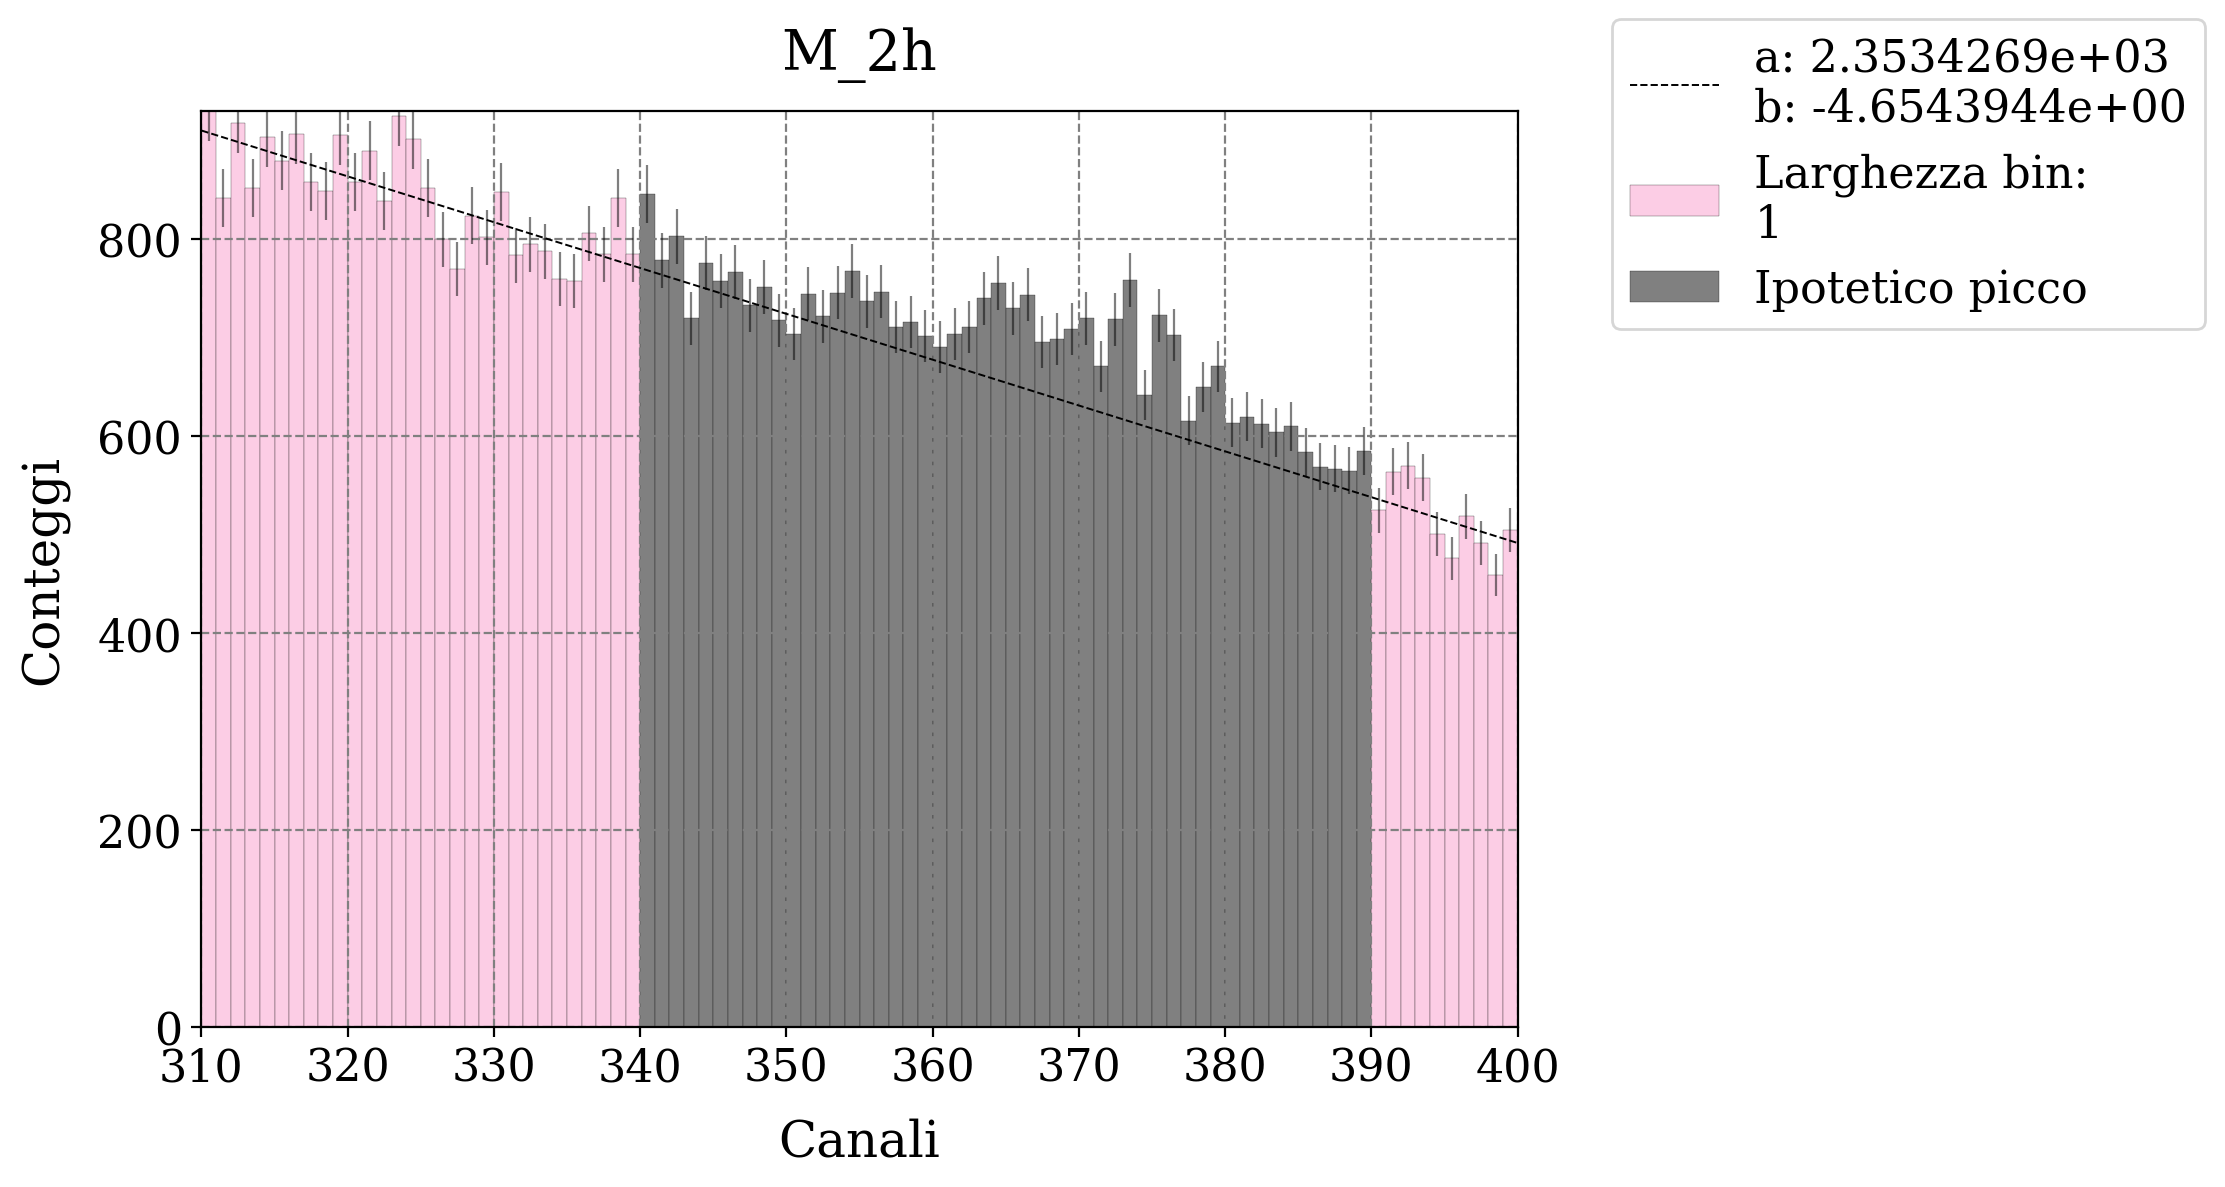

Fit Lineare


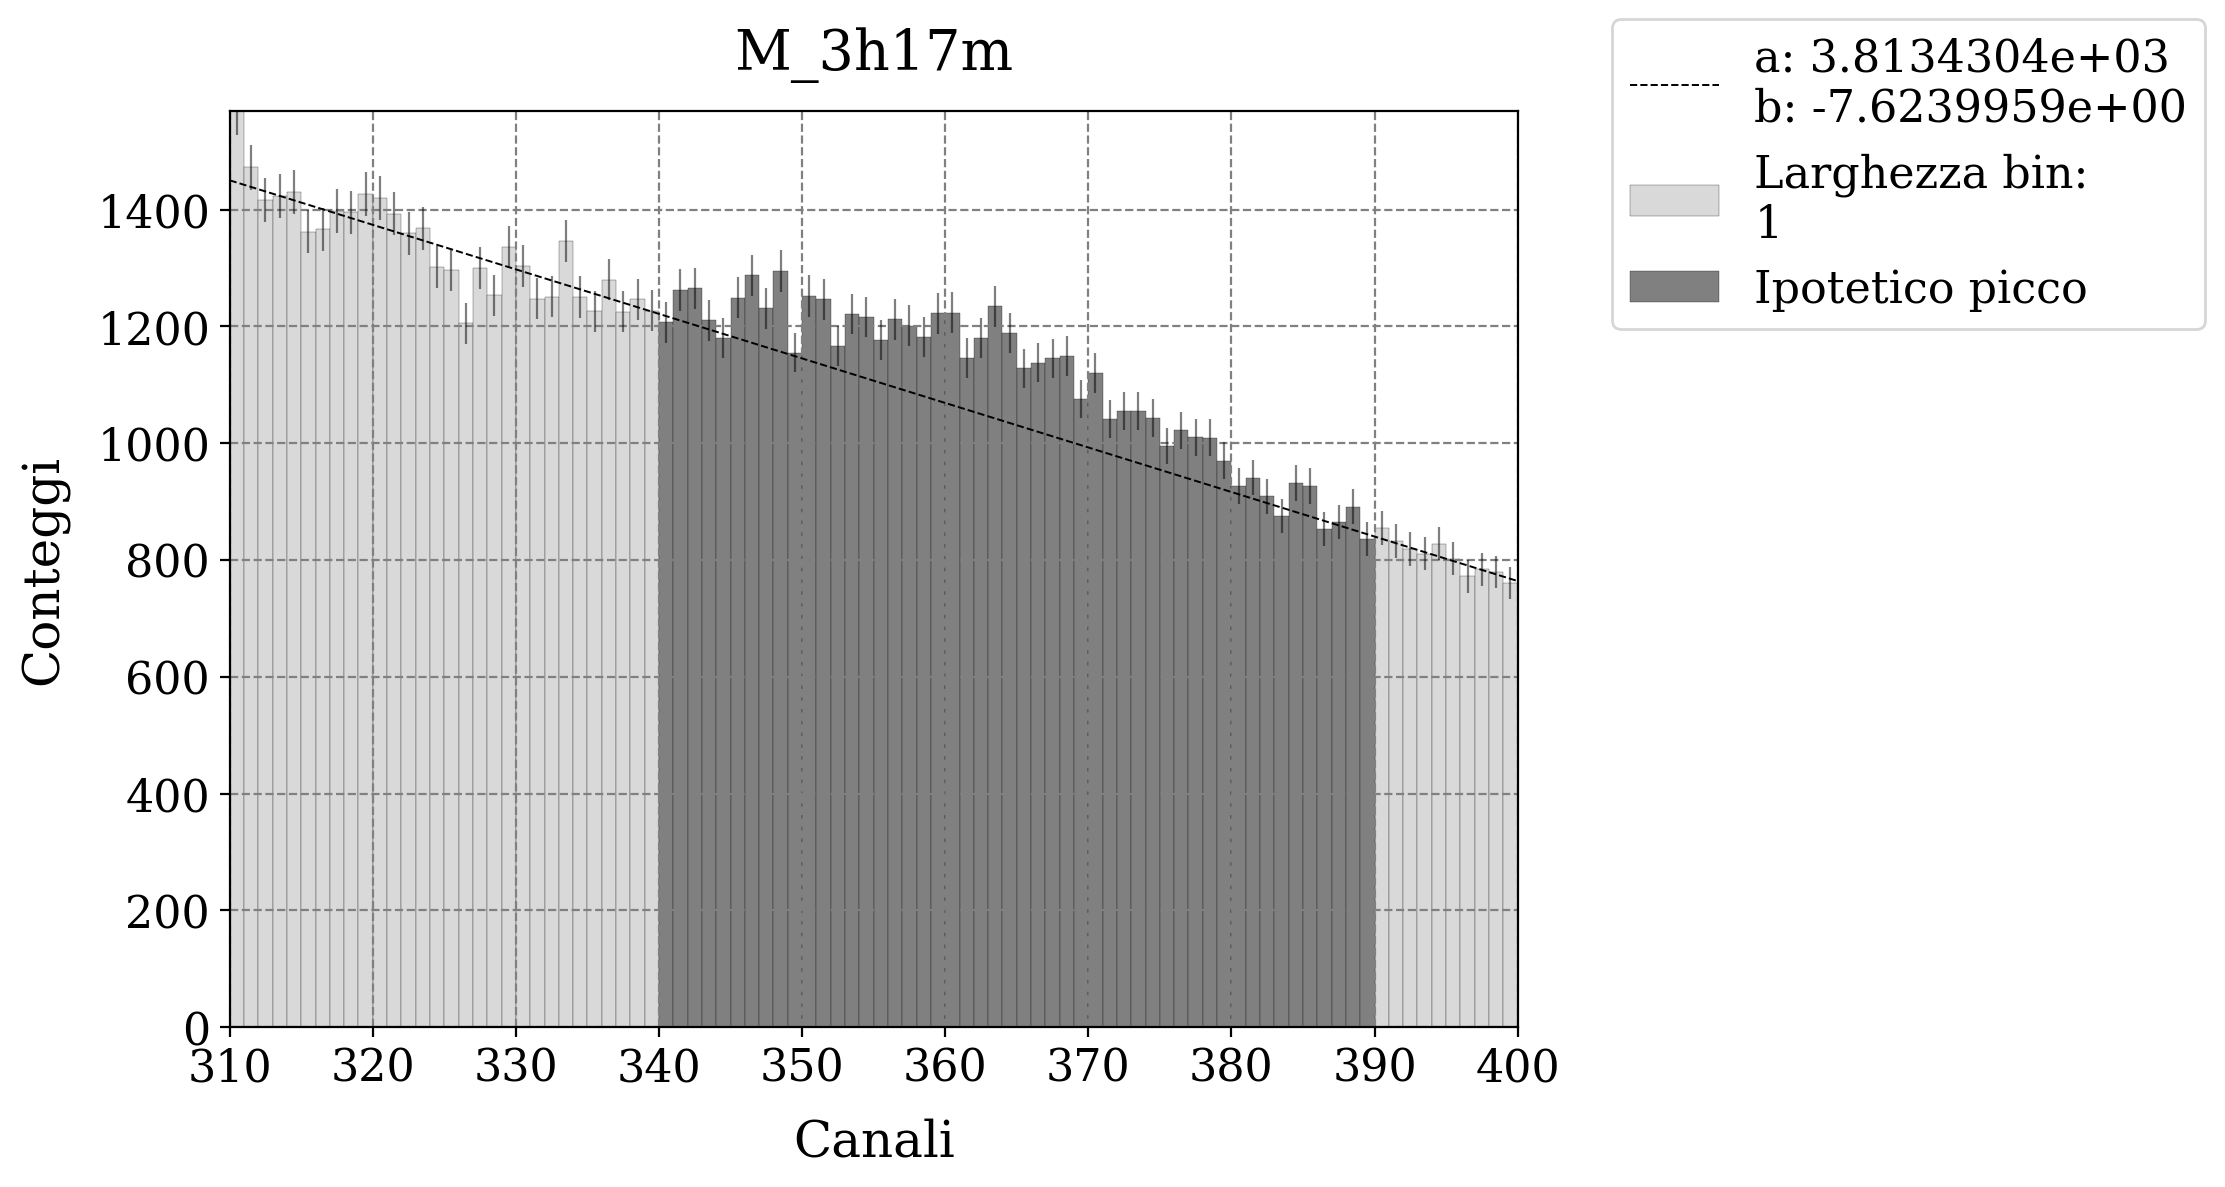

Fit Lineare


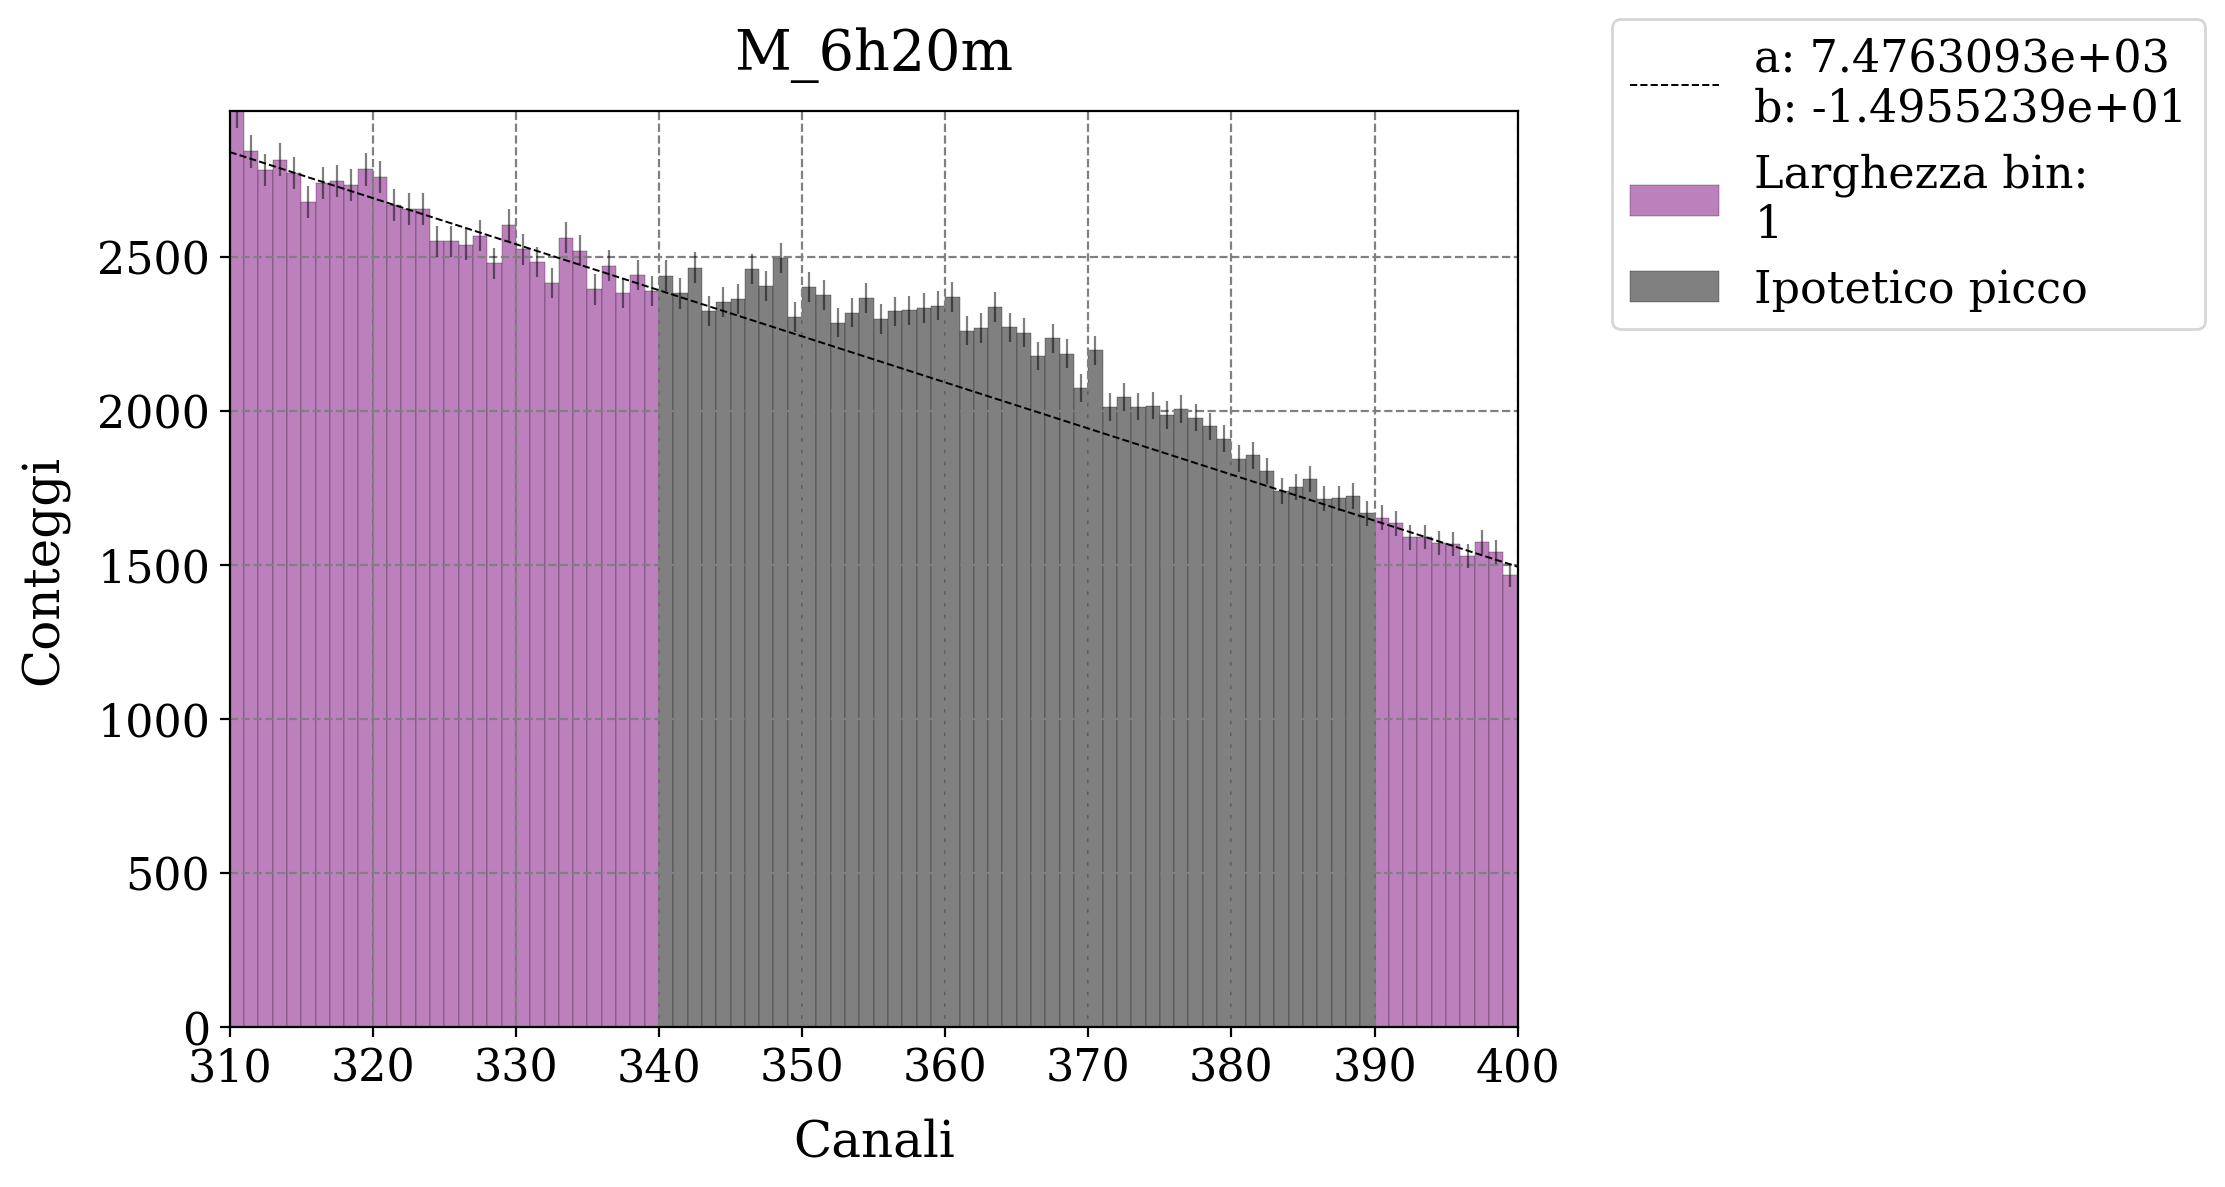

Fit Lineare


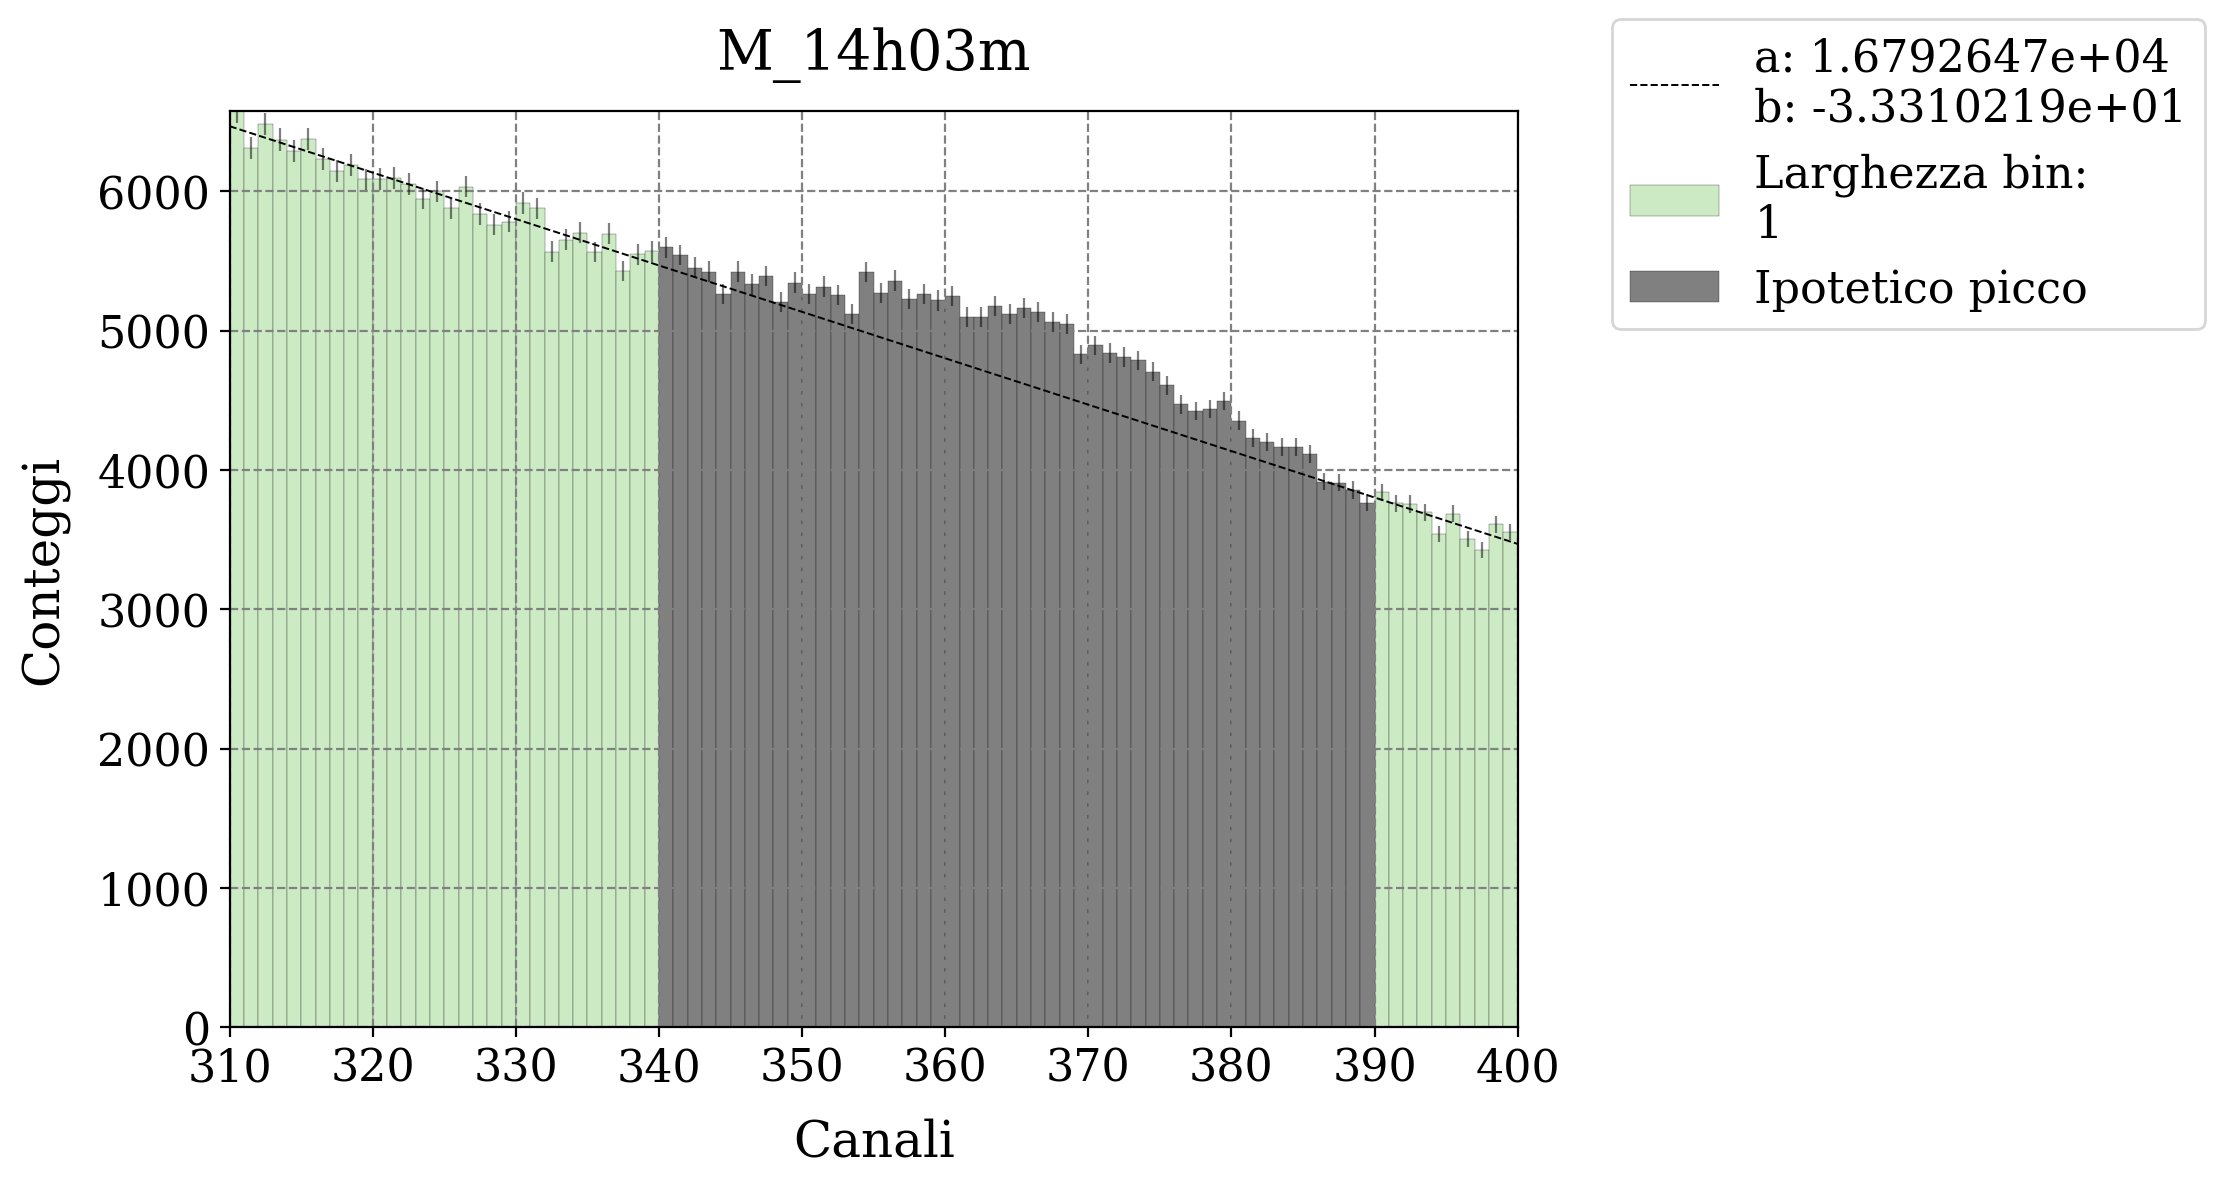

Fit Lineare


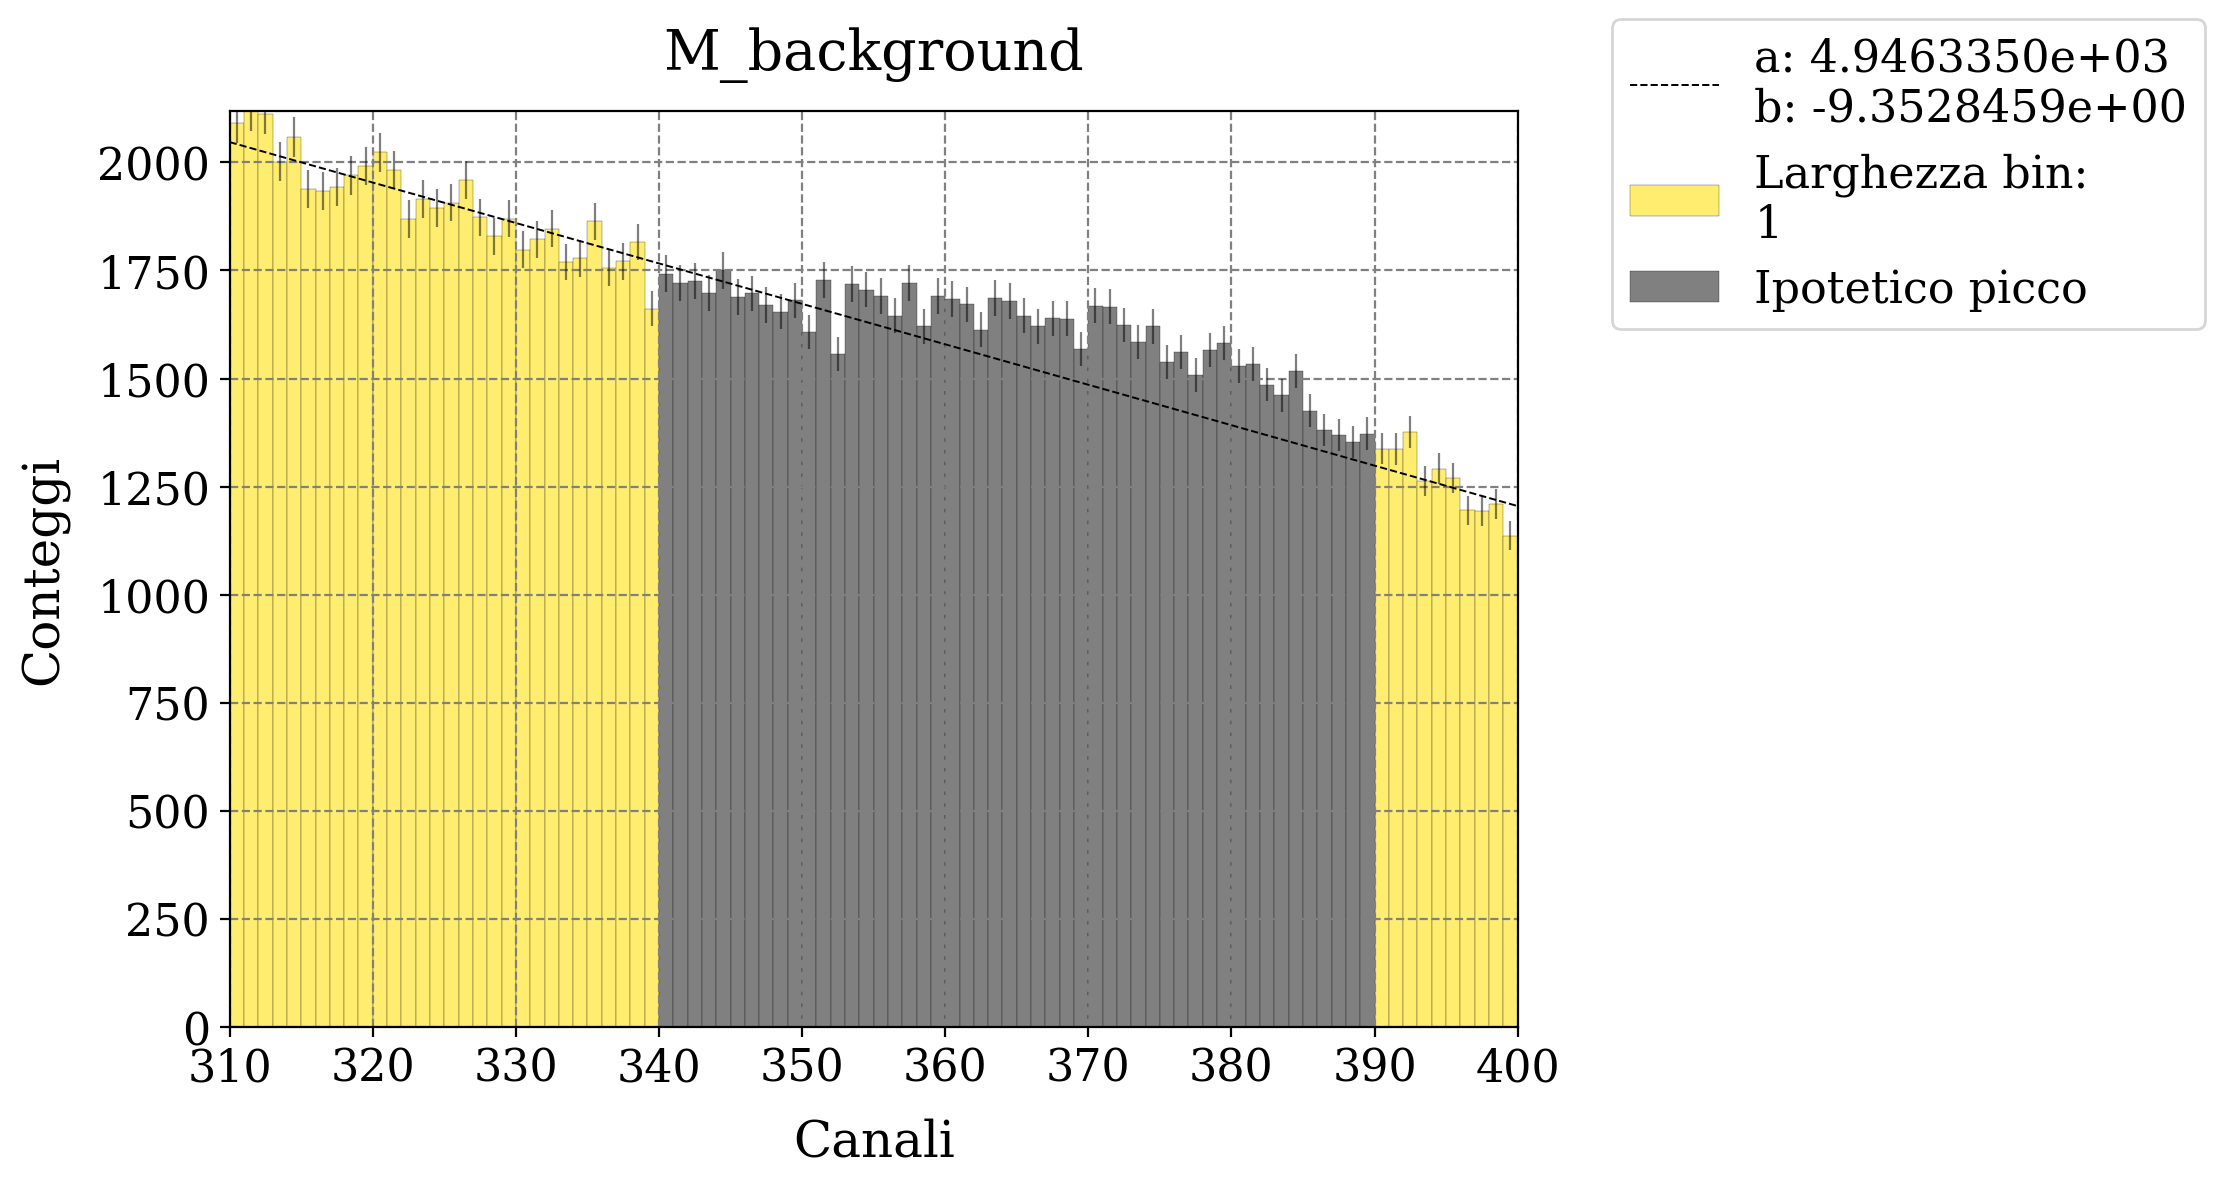

Fit Lineare


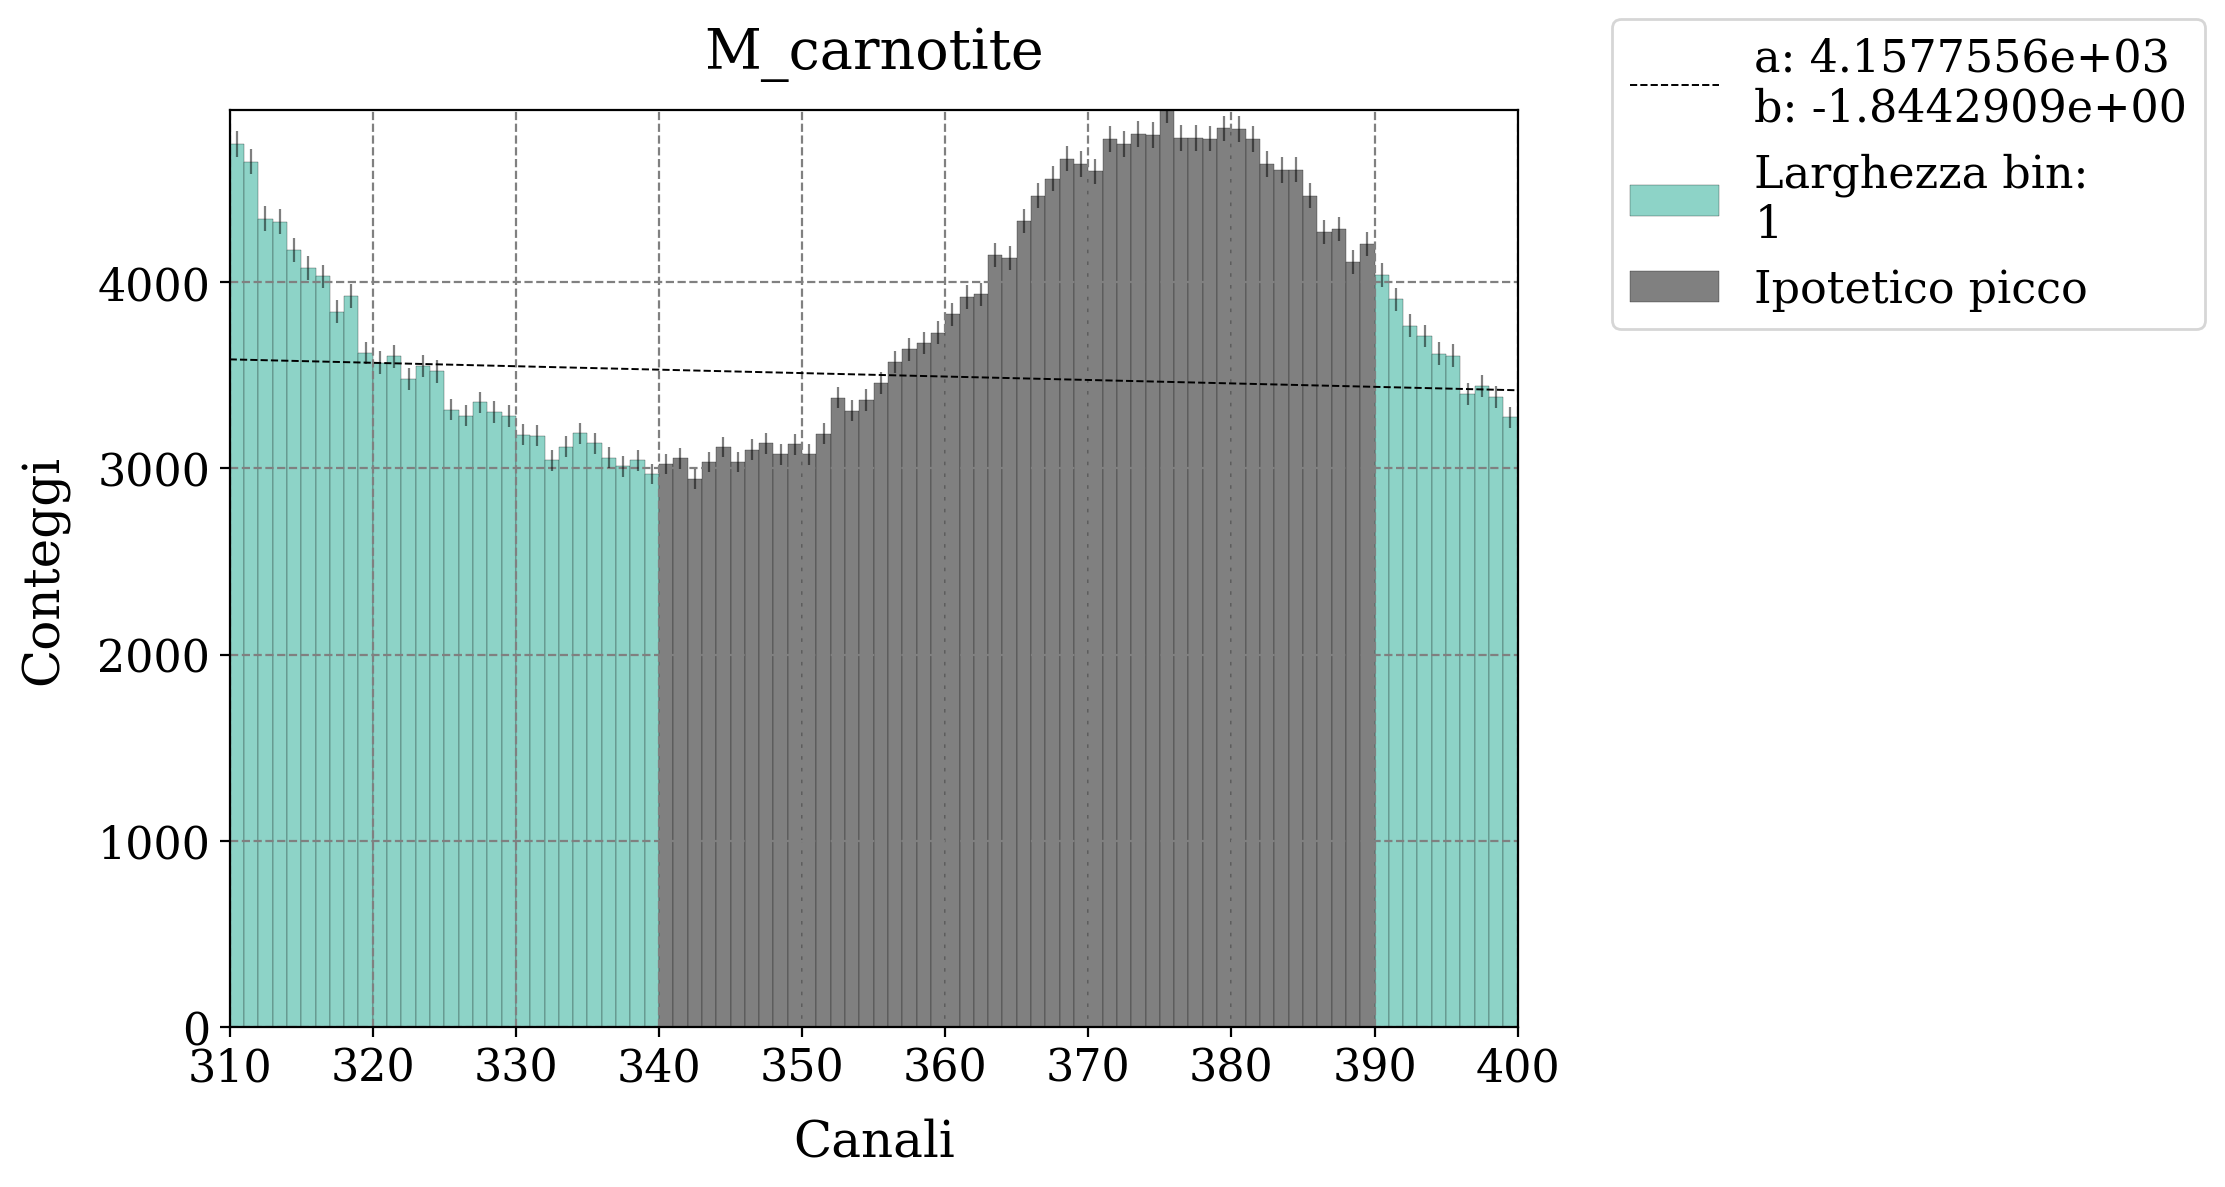

In [534]:
gf.imposta_stile_globale()
cmap = plt.get_cmap('Set3')
color_cycle = itertools.cycle(cmap.colors)

centri_storage,frequenze_storage,a_storage,b_storage,sigma_storage,sa_storage,sb_storage,cov_storage,chi_storage=[],[],[],[],[],[],[],[],[]

for file, titolo in zip(output_files, titoli):
    dati = np.loadtxt(file)
    centri = dati[:,0].tolist()
    centri_storage.append(centri[i2:i3])
    frequenze = dati[:,1].tolist()
    frequenze_storage.append(frequenze[i2:i3])
    output = file.replace("Ispector_65_Spectrum","elaborato").replace("Data","Elaborati")

# Fitting
    xdata = np.array(centri[i1:i2] + centri[i3:i4])
    ydata = np.array(frequenze[i1:i2] + frequenze[i3:i4])
    a,b,sa,sb,cov,chi = f.elaborato(xdata,ydata,np.sqrt(ydata),output,0,ritorno=True)
    a_storage.append(a)
    b_storage.append(b)
    sa_storage.append(sa)
    sb_storage.append(sb)
    cov_storage.append(cov)
    chi_storage.append(chi)

# Grafico Curva Fit
    x = np.linspace(i1, i4, 100)
    y = lin_func(x,a,b)

# Incertezze sulle colonne
    sydata = np.sqrt(frequenze)
    sigma_storage.append(sydata[i2:i3].tolist())

# Plotting
    fig, ax = plt.subplots()
    color=next(color_cycle)
    ax.plot(x,y, color = 'black', linestyle = '--', linewidth=0.7, label =f"a: {a:.7e}\nb: {b:.7e}")
    ax.bar(xdata,ydata, width=centri[1]-centri[0], color=color, edgecolor='black', linewidth=0.1, label=f"Larghezza bin:\n{bin}")
    xdata = np.array(centri[i2:i3])
    ydata = np.array(frequenze[i2:i3])
    ax.bar(xdata,ydata, width=centri[1]-centri[0], color="gray", edgecolor='black', linewidth=0.1, label="Ipotetico picco")

# Aggiunta delle barre d'errore
    ax.errorbar(centri, frequenze, yerr=sydata, fmt='none', ecolor='black', elinewidth=0.8, alpha=0.5)
    if bin == 1:
        xlabel = "Canali"
    else:
        xlabel = f"Canali (diviso {bin})"
    plt.xlim(i1,i4)
    plt.ylim(0,np.max(frequenze[i1:i4]))
    gf.parametri_grafico(ax, titolo=titolo, xlabel=xlabel, ylabel="Conteggi")

# Salvataggio
    gf.salva_grafico(fig, file.replace('txt','pdf').replace('Data','Images'))

### 2.3 Grafico Generale

In [535]:
"""for file, titolo in zip(output_files, titoli):
    dati = np.loadtxt(file)
    centri = dati[:,0].tolist()
    frequenze = dati[:,1].tolist()

# Incertezze sulle colonne
    sydata = np.sqrt(frequenze)

# Plotting
    fig, ax = plt.subplots()
    color=next(color_cycle)
    ax.bar(centri,frequenze, width=centri[1]-centri[0], color=color, linewidth=0.1, label=f"Larghezza bin:\n{bin}")

# Aggiunta delle barre d'errore
    #ax.errorbar(centri, frequenze, yerr=sydata, fmt='none', ecolor='black', elinewidth=0.8, alpha=0.5)
    if bin == 1:
        xlabel = "Canali"
    else:
        xlabel = f"Canali (diviso {bin})"
    plt.ylim(0,np.max(frequenze))
    gf.parametri_grafico(ax, titolo=titolo, xlabel=xlabel, ylabel="Conteggi")

# Salvataggio
    gf.salva_grafico(fig, file.replace('txt','pdf').replace('Data','Images/Esponenziale'))"""

'for file, titolo in zip(output_files, titoli):\n    dati = np.loadtxt(file)\n    centri = dati[:,0].tolist()\n    frequenze = dati[:,1].tolist()\n\n# Incertezze sulle colonne\n    sydata = np.sqrt(frequenze)\n\n# Plotting\n    fig, ax = plt.subplots()\n    color=next(color_cycle)\n    ax.bar(centri,frequenze, width=centri[1]-centri[0], color=color, linewidth=0.1, label=f"Larghezza bin:\n{bin}")\n\n# Aggiunta delle barre d\'errore\n    #ax.errorbar(centri, frequenze, yerr=sydata, fmt=\'none\', ecolor=\'black\', elinewidth=0.8, alpha=0.5)\n    if bin == 1:\n        xlabel = "Canali"\n    else:\n        xlabel = f"Canali (diviso {bin})"\n    plt.ylim(0,np.max(frequenze))\n    gf.parametri_grafico(ax, titolo=titolo, xlabel=xlabel, ylabel="Conteggi")\n\n# Salvataggio\n    gf.salva_grafico(fig, file.replace(\'txt\',\'pdf\').replace(\'Data\',\'Images/Esponenziale\'))'

# 3. Confronto Aree

In [536]:
print(f"i1: {i1}\ni2: {i2}\ni3: {i3}\ni4: {i4}\n\n")
print(f"centri: {centri_storage}\nfrequenze: {frequenze_storage}\nsigma frequenze: {sigma_storage}\na: {a_storage}\nb: {b_storage}\nsa: {sa_storage}\nsb: {sb_storage}\ncov: {cov_storage}\nChi: {chi_storage}")

i1: 310
i2: 340
i3: 390
i4: 400


centri: [[340.5, 341.5, 342.5, 343.5, 344.5, 345.5, 346.5, 347.5, 348.5, 349.5, 350.5, 351.5, 352.5, 353.5, 354.5, 355.5, 356.5, 357.5, 358.5, 359.5, 360.5, 361.5, 362.5, 363.5, 364.5, 365.5, 366.5, 367.5, 368.5, 369.5, 370.5, 371.5, 372.5, 373.5, 374.5, 375.5, 376.5, 377.5, 378.5, 379.5, 380.5, 381.5, 382.5, 383.5, 384.5, 385.5, 386.5, 387.5, 388.5, 389.5], [340.5, 341.5, 342.5, 343.5, 344.5, 345.5, 346.5, 347.5, 348.5, 349.5, 350.5, 351.5, 352.5, 353.5, 354.5, 355.5, 356.5, 357.5, 358.5, 359.5, 360.5, 361.5, 362.5, 363.5, 364.5, 365.5, 366.5, 367.5, 368.5, 369.5, 370.5, 371.5, 372.5, 373.5, 374.5, 375.5, 376.5, 377.5, 378.5, 379.5, 380.5, 381.5, 382.5, 383.5, 384.5, 385.5, 386.5, 387.5, 388.5, 389.5], [340.5, 341.5, 342.5, 343.5, 344.5, 345.5, 346.5, 347.5, 348.5, 349.5, 350.5, 351.5, 352.5, 353.5, 354.5, 355.5, 356.5, 357.5, 358.5, 359.5, 360.5, 361.5, 362.5, 363.5, 364.5, 365.5, 366.5, 367.5, 368.5, 369.5, 370.5, 371.5, 372.5, 373.5, 374.5, 375.5, 

### 3.1 Calcolo Area Segnale

In [537]:
segnali=[]
for frequenze,a,b in zip(frequenze_storage,a_storage,b_storage):
    integrale = a*(i3-i2) + b * (i3**2 - i2**2)/2
    somma = sum(frequenza for frequenza in frequenze)
    segnali.append(somma - integrale)
print(f"segnali: {segnali}")

segnali: [66.54983315864388, 200.9775971445024, 156.70759407694823, 363.75276799760104, 686.022698722627, 1499.2207503608806, 882.4011266463203, 2206.3519966108433, 3784.403051520989, 6625.639672285004, 13062.129314093385, 3890.684977005556, 25961.526667547587]


### 3.2 Incertezze Area Segnale

In [538]:
ssegnali=[]
for sigma, sa, sb, cov in zip(sigma_storage, sa_storage, sb_storage, cov_storage):
    ssomma = np.sqrt(sum(s**2 for s in sigma))
    dx=i3-i2
    mx = (i3+i2)/2
    sintegrale = np.sqrt(dx**2*sa**2 + dx**2*mx**2*sb**2 + 2*dx**2*mx*cov)
    ssegnali.append(np.sqrt(ssomma**2 + sintegrale**2))
print(f"ssegnali: {ssegnali}")

ssegnali: [35.504117983850314, 85.25300835869888, 114.34798266033494, 161.80566439539876, 197.27294778523245, 228.4318033685199, 228.4523430298662, 298.409400853849, 374.3651020397924, 522.9768562174281, 792.2314553787545, 458.38862065473216, 730.8379794066808]


### 3.3 Compatibilità Segnale con Zero

##### 3.3.1 Test Significanza

In [547]:
a1_storage=[]
for S,sS in zip(segnali,ssegnali):
    comp = S/sS
    a1_storage.append(comp)
print(f"Significanza: {a1_storage}")

Significanza: [1.8744257550325645, 2.3574252805120564, 1.3704447637037938, 2.2480842642734142, 3.4775305302858235, 6.563099919770137, 3.8625172976709705, 7.393708074536972, 10.108856383517107, 12.669087730204238, 16.487769105114072, 8.487743372530403, 35.52295775408941]


##### 3.3.2 Test Chi Quadro

In [548]:
b1_storage=[]
for S,sS in zip(segnali,ssegnali):
    comp = (S/sS)**2
    p = chi2.sf(comp, 1)
    z_score = norm.isf(p)
    b1_storage.append(z_score)
print(f"z-score: {b1_storage}")

z-score: [1.547496645096614, 2.0879281488765398, 0.9520015150044061, 1.9673607622517233, 3.2871383871477104, 6.458994397489039, 3.689778681473113, 7.301026993214777, 10.040714910367122, 12.614594956888373, 16.4458290366382, 8.40679228550313, 35.50345518158401]


### 3.4 Andamento Temporale Significanze

In [549]:
rows=[]
for titolo,c,chi,z in zip(titoli,a1_storage,chi_storage,b1_storage):
    rows.append([titolo,chi,c,z])
headers = ["Serie", "p-value fit", "Significanza", "z-score"]

print(f"Indici:\n{i1}\t{i2}\t{i3}\t{i4}\n")
print(tabulate.tabulate(rows, headers=headers, floatfmt=".5f"))

Indici:
310	340	390	400

Serie           p-value fit    Significanza    z-score
------------  -------------  --------------  ---------
2min                0.28433         1.87443    1.54750
11min               0.73668         2.35743    2.08793
20min               0.17005         1.37044    0.95200
40min               0.52194         2.24808    1.96736
1h                  0.23546         3.47753    3.28714
M_1h10m             0.04267         6.56310    6.45899
1h20m               0.69765         3.86252    3.68978
M_2h                0.02924         7.39371    7.30103
M_3h17m             0.21619        10.10886   10.04071
M_6h20m             0.54367        12.66909   12.61459
M_14h03m            0.12611        16.48777   16.44583
M_background        0.01755         8.48774    8.40679
M_carnotite         0.00000        35.52296   35.50346
